# Matrix-free operators — acting on a many-body state with einsum

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 3 — The matrix-free engine*

## 1. Introduction and motivation

In the two previous notebooks we did many-body quantum mechanics *the textbook way*. A chain of $N$ spins-1/2 lives in a
Hilbert space of dimension $2^N$; an operator that acts on a single spin $q$ was written as a Kronecker product

$$ M_q \;=\; \underbrace{\mathbb 1\otimes\dots\otimes\mathbb 1}_{q}\otimes M\otimes\underbrace{\mathbb 1\otimes\dots\otimes\mathbb 1}_{N-q-1}, $$

a matrix with $2^N\times 2^N = 4^N$ entries, and the Hamiltonian and the Trotter gates were sums and products of such
matrices. That approach is perfectly correct, and it collapses at $N\approx 12$–$14$: for $N=14$ a single dense operator
in double precision occupies $16\cdot 4^{14}$ bytes $\approx 4.3$ GB, and for $N=20$ it would need $17.6$ **tera**bytes.

Look again at the formula above. Almost all of that gigantic matrix is *identity*. The only non-trivial information in
$M_q$ are the **four numbers** of the $2\times2$ matrix $M$ and the **integer** $q$. It must be possible to act with
$M_q$ on a state using only those — and it is. The trick is a change of viewpoint:

> a state of $N$ spins is not "a vector of length $2^N$" but **an array with $N$ indices, each running over 2 values**
> — a rank-$N$ tensor $\psi[s_0,s_1,\dots,s_{N-1}]$ — and an operator on spin $q$ is a small matrix **contracted with index $q$**.

This is what *matrix-free* means: the operator exists only through its **action** on a state; the $2^N\times2^N$ matrix
is never formed. Memory drops from $O(4^N)$ to $O(2^N)$ and the work per operator from $O(4^N)$ to $O(2^k\,2^N)$ for an
operator on $k$ spins. On a laptop this moves the wall from $N\approx 13$ to $N\approx 25$–$30$, and it is how every
serious state-vector simulator — for spin chains, cold atoms or quantum computers — works. **Everything in the rest
of this course is built on the single function `apply_gate` that we derive in this notebook.**

**Why should you care?** Experiments with Rydberg-atom arrays, trapped ions and superconducting circuits today control
$N = 20$–$100$ two-level systems and watch their quantum dynamics. To interpret such experiments, to benchmark quantum
hardware, or to explore many-body physics on your own, you need exact numerics at the largest $N$ you can afford.
The difference between $N=12$ and $N=24$ is the difference between a toy and a research tool.

### Road map

1. **State vector → tensor** (§2): `reshape`, "axis $q$ = spin $q$", the flat-index formula.
2. **One-site operators** (§3): derive $\psi'[..a..]=\sum_b M[a,b]\,\psi[..b..]$, write the einsum strings by hand for $N=3$
   and check every one against the Kronecker matrix of notebook 03.
3. **Two-site operators** (§4): reshape $4\times4\to(2,2,2,2)$, which index is which, neighbours, distant sites, reversed order.
4. **The general `apply_gate`** (§5): building the einsum string programmatically, line by line; the production version.
5. **Alternative implementations and a benchmark** (§6): einsum vs reshape+matmul vs tensordot vs dense, time and memory vs $N$.
6. **Matrix-free $H|\psi\rangle$** (§7): a Hamiltonian is a *list of local terms*; validation against the dense Hamiltonian.
7. **The first matrix-free time evolution** (§8): Trotter gates $e^{-ih\,dt}$ applied by einsum (this *is* the TEBD algorithm on a
   state vector), `jit` + `lax.scan`, machine-precision agreement with the dense Trotter code, then a quench of **$N=20$ spins**.
8. **Cost model** $O(2^k 2^N)$ confronted with measurements (§9).

### What you will learn

*Physics*

* why local operators never need the full Hilbert-space matrix, and what "locality" means for an algorithm;
* the quench dynamics of the transverse-field Ising chain for 20 spins: decay of the magnetisation, a light cone of correlations, the Loschmidt echo.

*Numerical methods*

* the tensor form of a many-body state and the C-ordered flat-index formula;
* operators as index contractions; conventions for two-site operators (row/column, first qubit = left Kronecker factor);
* matrix-free matrix–vector products $H|\psi\rangle$ and Trotterised evolution; the cost model $O(2^k2^N)$ time, $O(2^N)$ memory.

*Implementation practice*

* constructing einsum strings by program; static (Python) versus traced (JAX) arguments;
* validating every new primitive against an independent brute-force reference on small $N$;
* benchmarking: compile time vs run time, `block_until_ready`, best-of-several, scaling rather than absolute numbers;
* `jax.jit`, `jax.vmap` and `jax.lax.scan` at work in a real simulation.

### Prerequisites

* [01 — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `lax.scan`, timing compiled code.
* [02 — einsum from scratch](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb): the three rules of einsum, `reshape` and C-ordering, building strings by program.
* [03 — Quantum many-body spin systems](../ch02_spin_systems_textbook_way/03_quantum_many_body_spin_systems.ipynb): Kronecker products, `site_operator`, dense Hamiltonians, the transverse-field Ising model.
* [04 — Time evolution the textbook way](../ch02_spin_systems_textbook_way/04_time_evolution_the_textbook_way.ipynb): Trotterization with dense matrices, the TFIM quench.

The few dense helpers we need from notebooks 03–04 are re-defined below.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. A state vector is a rank-$N$ tensor

### 2.1 Notation and conventions

| symbol | meaning |
|---|---|
| $N$ | number of spins-1/2 (qubits), labelled $q = 0,1,\dots,N-1$ from left to right |
| $s_q\in\{0,1\}$ | basis label of spin $q$: $\lvert0\rangle=(1,0)^T$ is "up" ($Z=+1$), $\lvert1\rangle=(0,1)^T$ is "down" ($Z=-1$) |
| $\lvert s_0s_1\dots s_{N-1}\rangle$ | product basis state $\lvert s_0\rangle\otimes\lvert s_1\rangle\otimes\dots\otimes\lvert s_{N-1}\rangle$ |
| $\psi_i$ | component $i=0,\dots,2^N-1$ of the state **vector** (notebook 03) |
| $\psi[s_0,\dots,s_{N-1}]$ | the same number, stored in a **tensor** of shape $(2,2,\dots,2)$ |
| $X,Y,Z$ | Pauli matrices; Hamiltonians are written with Pauli matrices (not spin-1/2 operators $S=\sigma/2$) |

A general state is

$$ |\psi\rangle=\sum_{s_0=0}^{1}\cdots\sum_{s_{N-1}=0}^{1}\psi[s_0,s_1,\dots,s_{N-1}]\;|s_0s_1\dots s_{N-1}\rangle . $$

The amplitudes carry $N$ binary indices — they *are* an array with $N$ axes. In notebook 03 we nevertheless stored them in a
one-dimensional vector, numbering the basis states by reading the bit string as a binary number:

$$ i \;=\; s_0\,2^{N-1}+s_1\,2^{N-2}+\dots+s_{N-1}\,2^{0}\;=\;\sum_{q=0}^{N-1}s_q\,2^{\,N-1-q}. \tag{1} $$

Spin 0 is the **most significant bit**. This was not a free choice: it is forced by the Kronecker product, because in
$u\otimes v$ the index of the *left* factor varies slowest.

Now the key observation. Equation (1) is *exactly* the rule by which NumPy/JAX lay out a multi-dimensional array in memory
("C order" or "row-major": the **last index runs fastest**, see notebook 02). Therefore

$$ \texttt{psi\_tensor = psi\_vector.reshape((2,)*N)} \qquad\Longleftrightarrow\qquad \psi[s_0,\dots,s_{N-1}] = \psi_{i(s_0,\dots,s_{N-1})} $$

without moving a single number in memory. `reshape` only changes how we *address* the $2^N$ amplitudes: with one big index
$i$, or with $N$ small ones. **Axis $q$ of the tensor is spin $q$.**

We first re-create the small dense toolbox of notebook 03, which will serve as the independent reference for everything we build.

In [2]:
# ==============================================================================
# STEP 0: the dense "textbook" toolbox from notebooks 03-04 (our reference)
# ==============================================================================
from functools import reduce

# Pauli matrices; |0> = (1,0) is the +1 eigenstate of Z ("spin up")
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)


def site_operator(op, j, N):
    """Dense 2^N x 2^N matrix of a single-site operator (the textbook construction of notebook 03).

    MATH   op_j = 1 (x) ... (x) 1 (x) op (x) 1 (x) ... (x) 1      (op at position j, N factors)
    COST   O(4^N) memory and time -- this is the wall we are about to remove.  VALIDATION ONLY.
    """
    factors = [op if q == j else I2 for q in range(N)]
    return reduce(jnp.kron, factors)


def two_site_operator(h2, j, N):
    """Dense matrix of a 4x4 operator on the NEIGHBOURING spins (j, j+1) (notebooks 03-04).

    MATH   h_{j,j+1} = 1_{2^j} (x) h2 (x) 1_{2^(N-j-2)};  spin j is the LEFT Kronecker factor of h2.   VALIDATION ONLY.
    """
    left, right = jnp.eye(2 ** j, dtype=CDTYPE), jnp.eye(2 ** (N - j - 2), dtype=CDTYPE)
    return jnp.kron(jnp.kron(left, jnp.asarray(h2, dtype=CDTYPE)), right)


def random_state(key, N):
    """Normalised random complex state VECTOR of length 2^N (complex Gaussian amplitudes).

    JAX    randomness is explicit: the same `key` always gives the same state (reproducible notebooks);
           `jax.random.split` makes independent keys (see notebook 01).
    """
    k_re, k_im = jax.random.split(key)
    v = jax.random.normal(k_re, (2 ** N,), dtype=RDTYPE) + 1j * jax.random.normal(k_im, (2 ** N,), dtype=RDTYPE)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


def random_matrix(key, d):
    """Random complex d x d matrix (neither Hermitian nor unitary): the most demanding test operator."""
    k_re, k_im = jax.random.split(key)
    return (jax.random.normal(k_re, (d, d), dtype=RDTYPE) + 1j * jax.random.normal(k_im, (d, d), dtype=RDTYPE)).astype(CDTYPE)


def max_abs_diff(a, b):
    """Largest element-wise deviation between two arrays of any (equal-size) shape: our error measure."""
    return float(jnp.max(jnp.abs(jnp.ravel(a) - jnp.ravel(b))))


key = jax.random.PRNGKey(2026)          # master key of this notebook; split deterministically below
print("site_operator(Z, 1, 3) has shape", site_operator(Z, 1, 3).shape, "  two_site_operator(kron(Z,Z), 0, 3) has shape", two_site_operator(jnp.kron(Z, Z), 0, 3).shape)

site_operator(Z, 1, 3) has shape (8, 8)   two_site_operator(kron(Z,Z), 0, 3) has shape (8, 8)


### 2.2 Reshape: from one big index to $N$ small ones

Take $N=3$. To *see* where every number goes we fill the vector with the recognisable "amplitudes"
$\psi_i = i$ (not normalised — this is bookkeeping, not physics), reshape, and check Eq. (1) for all 8 basis states.

In [3]:
# ==============================================================================
# STEP 1: state vector -> rank-N tensor is a reshape (C order: last index fastest)
# ==============================================================================
N = 3
psi_vec = jnp.arange(2 ** N, dtype=RDTYPE).astype(CDTYPE)      # psi_i = i : every amplitude "knows" its flat index
psi_ten = psi_vec.reshape((2,) * N)                            # shape (2, 2, 2): axis q = spin q

print("vector shape:", psi_vec.shape, "   tensor shape:", psi_ten.shape, "\n")
print("  s0 s1 s2 | flat index i = 4 s0 + 2 s1 + s2 | psi_tensor[s0,s1,s2]")
print("  ---------+---------------------------------+---------------------")
for s0 in range(2):
    for s1 in range(2):
        for s2 in range(2):
            i = s0 * 2 ** 2 + s1 * 2 ** 1 + s2 * 2 ** 0           # Eq. (1)
            amp = psi_ten[s0, s1, s2]
            assert abs(amp - i) < TOL                             # tensor entry == vector entry number i
            print(f"   {s0}  {s1}  {s2} |               {i}                 |        {amp.real:.0f}")

# NumPy knows Eq. (1) too:
assert np.ravel_multi_index((1, 0, 1), (2, 2, 2)) == 5           # (s0,s1,s2) -> i
assert np.unravel_index(5, (2, 2, 2)) == (1, 0, 1)               # i -> (s0,s1,s2)
# and going back is again just a reshape:
assert max_abs_diff(psi_ten.reshape(-1), psi_vec) < TOL
print("\nCHECKPOINT passed: psi_tensor[s0,s1,s2] == psi_vector[4 s0 + 2 s1 + s2] for all 8 basis states.")

vector shape: (8,)    tensor shape: (2, 2, 2) 

  s0 s1 s2 | flat index i = 4 s0 + 2 s1 + s2 | psi_tensor[s0,s1,s2]
  ---------+---------------------------------+---------------------
   0  0  0 |               0                 |        0
   0  0  1 |               1                 |        1
   0  1  0 |               2                 |        2
   0  1  1 |               3                 |        3
   1  0  0 |               4                 |        4
   1  0  1 |               5                 |        5
   1  1  0 |               6                 |        6
   1  1  1 |               7                 |        7



CHECKPOINT passed: psi_tensor[s0,s1,s2] == psi_vector[4 s0 + 2 s1 + s2] for all 8 basis states.


The table is Eq. (1) at work: the entry stored at position $[s_0,s_1,s_2]$ of the tensor is the amplitude number
$4s_0+2s_1+s_2$ of the vector. The picture below shows the same thing geometrically: for $N=3$ the tensor is a
$2\times2\times2$ cube whose corners are the 8 basis states; moving along axis $q$ flips spin $q$ and changes the flat index
by the **stride** $2^{N-1-q}$ (4, 2, 1 for $q=0,1,2$).

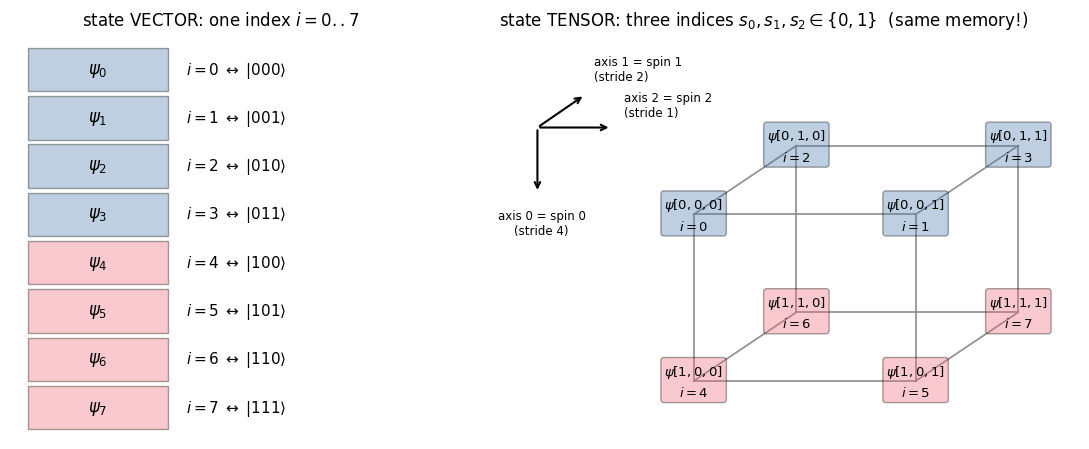

In [4]:
# ==============================================================================
# FIGURE: the same 8 amplitudes as a vector and as a 2x2x2 tensor
# ==============================================================================
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw={"width_ratios": [1, 1.5]})
colors = {0: "#4477AA", 1: "#EE6677"}                       # colour = value of s0 (the most significant bit)

# --- left: the vector, one box per flat index -----------------------------------------------
for i in range(8):
    bits = format(i, "03b")
    axL.add_patch(plt.Rectangle((0, 7 - i), 1.6, 0.9, facecolor=colors[int(bits[0])], alpha=0.35, edgecolor="k"))
    axL.text(0.8, 7 - i + 0.45, rf"$\psi_{i}$", ha="center", va="center", fontsize=12)
    axL.text(1.8, 7 - i + 0.45, rf"$i={i}\;\leftrightarrow\;|{bits}\rangle$", ha="left", va="center", fontsize=11)
axL.set_xlim(-0.2, 4.6); axL.set_ylim(-0.2, 8.2); axL.axis("off")
axL.set_title("state VECTOR: one index $i=0..7$")

# --- right: the cube; corner (s0,s1,s2) drawn in an oblique projection ----------------------
def corner(s0, s1, s2):
    """2D drawing position of tensor entry [s0,s1,s2]: axis 2 -> right, axis 0 -> down, axis 1 -> into the page."""
    return np.array([2.7 * s2 + 1.25 * s1, -2.3 * s0 + 0.95 * s1])

for s0 in range(2):
    for s1 in range(2):
        for s2 in range(2):
            p = corner(s0, s1, s2)
            for axis, nb in enumerate([(1, s1, s2), (s0, 1, s2), (s0, s1, 1)]):      # edges towards larger index
                if (s0, s1, s2)[axis] == 0:
                    pn = corner(*nb)
                    axR.plot([p[0], pn[0]], [p[1], pn[1]], color="0.55", lw=1.2, zorder=1)
for s0 in range(2):
    for s1 in range(2):
        for s2 in range(2):
            p = corner(s0, s1, s2)
            i = 4 * s0 + 2 * s1 + s2
            axR.text(p[0], p[1], rf"$\psi[{s0},{s1},{s2}]$" + f"\n$i={i}$", ha="center", va="center", fontsize=9.5, zorder=3, linespacing=1.5,
                     bbox=dict(boxstyle="round,pad=0.25", facecolor=colors[s0], alpha=0.35, edgecolor="k"))
o = np.array([-1.9, 1.2])                                                          # little coordinate frame
for d, lab in [((0.0, -1.0), "axis 0 = spin 0\n(stride 4)"), ((0.64, 0.5), "axis 1 = spin 1\n(stride 2)"),
               ((1.0, 0.0), "axis 2 = spin 2\n(stride 1)")]:
    d = np.array(d)
    axR.annotate("", xy=o + 0.9 * d, xytext=o, arrowprops=dict(arrowstyle="->", lw=1.5))
    axR.text(*(o + 1.0 * d + np.array([0.05, -0.12 if d[1] < 0 else 0.12])), lab, fontsize=8.5,
             ha="left" if d[0] > 0 else "center", va="top" if d[1] < 0 else "bottom")
axR.set_xlim(-3.0, 4.7); axR.set_ylim(-3.1, 2.5); axR.axis("off")
axR.set_title("state TENSOR: three indices $s_0,s_1,s_2\\in\\{0,1\\}$  (same memory!)")
plt.tight_layout(); plt.show()

**Reading the figure.** Left: the vector of notebook 03, one box per flat index. Right: the same eight numbers at the corners
of a cube. Blue corners have $s_0=0$ (first half of the vector), red corners $s_0=1$ (second half): axis 0 has the largest
stride. Neighbouring corners along axis 2 are neighbours in the vector (stride 1).

> **Numerical practice.** `reshape` is free: no data are copied, only the *shape* and *strides* attached to the memory
> block change. We can therefore hop between the two pictures whenever convenient — the vector picture for linear
> algebra (`vdot`, norms, dense reference checks), the tensor picture for applying local operators.

> **Common pitfall.** Some books and libraries use the opposite, "little-endian" convention (spin 0 = *least* significant
> bit). Nothing physical depends on it, but mixing conventions silently mirrors your chain. In this course: **spin $q$ =
> tensor axis $q$ = $q$-th factor of the Kronecker product, counted from the left**.

A product state makes the tensor structure explicit. For $|\psi\rangle=|u\rangle\otimes|v\rangle\otimes|w\rangle$ the amplitudes
are $\psi[s_0,s_1,s_2]=u[s_0]\,v[s_1]\,w[s_2]$, an outer product — in einsum language `"a,b,c->abc"` (no index is summed). Let us
confirm that this equals the Kronecker product of notebook 03 once reshaped.

In [5]:
# ==============================================================================
# CHECKPOINT: product state as outer product (tensor) == kron (vector)
# ==============================================================================
k_u, k_v, k_w, key = jax.random.split(key, 4)
u, v, w = (random_state(k, 1) for k in (k_u, k_v, k_w))          # three random single-spin states (length 2)

psi_kron = jnp.kron(jnp.kron(u, v), w)                           # notebook 03: vector of length 8
psi_outer = jnp.einsum("a,b,c->abc", u, v, w)                    # tensor of shape (2,2,2)

err = max_abs_diff(psi_outer.reshape(-1), psi_kron)
print(f"| einsum('a,b,c->abc') - kron(kron(u,v),w) |_max = {err:.2e}")
assert err < TOL

| einsum('a,b,c->abc') - kron(kron(u,v),w) |_max = 0.00e+00


The error is exactly zero (both routes perform the same multiplications): the Kronecker product **is** the outer product
followed by a reshape, with the left factor on the first axis.

## 3. One-site operators: contraction with axis $q$

### 3.1 Derivation

Let $M$ be a $2\times2$ matrix acting on spin $q$, i.e. the operator $M_q=\mathbb 1\otimes\dots\otimes M\otimes\dots\otimes\mathbb 1$.
Its matrix elements between product basis states factorise — every identity contributes a Kronecker delta:

$$ \langle s_0\dots s_{N-1}|M_q|s'_0\dots s'_{N-1}\rangle \;=\; \delta_{s_0s'_0}\cdots\delta_{s_{q-1}s'_{q-1}}\;M[s_q,s'_q]\;\delta_{s_{q+1}s'_{q+1}}\cdots\delta_{s_{N-1}s'_{N-1}} . $$

Acting on $|\psi\rangle$ means $\psi'[s]=\sum_{s'}\langle s|M_q|s'\rangle\,\psi[s']$. The $N-1$ deltas eat $N-1$ of the $N$
sums and only the sum over $s'_q$ survives:

$$ \boxed{\;\psi'[s_0,\dots,s_{q-1},\,a\,,s_{q+1},\dots,s_{N-1}] \;=\; \sum_{b=0}^{1} M[a,b]\;\psi[s_0,\dots,s_{q-1},\,b\,,s_{q+1},\dots,s_{N-1}]\;} \tag{2} $$

In words: *all other indices are spectators*; for every fixed value of the spectators, the two numbers
$\psi[\dots,0,\dots]$ and $\psi[\dots,1,\dots]$ form a little 2-component vector which is multiplied by the $2\times2$ matrix $M$.
There are $2^{N-1}$ such pairs, so the whole operation costs $2^{N-1}\times 4 = 2\cdot2^N$ multiplications — instead of the
$4^N$ of a dense matrix–vector product. The identities cost nothing because *doing nothing* is free.

### 3.2 Hand-written einsum strings for $N=3$

Equation (2) is a sum over one repeated index, which is precisely what `einsum` executes (notebook 02). Label the axes of
$\psi$ with the letters `a b c`. We adopt the mnemonic **"the new index is the capital letter of the old one"**:

| target | formula | einsum string |
|---|---|---|
| $q=0$ | $\psi'[A,b,c]=\sum_a M[A,a]\,\psi[a,b,c]$ | `"Aa,abc->Abc"` |
| $q=1$ | $\psi'[a,B,c]=\sum_b M[B,b]\,\psi[a,b,c]$ | `"Bb,abc->aBc"` |
| $q=2$ | $\psi'[a,b,C]=\sum_c M[C,c]\,\psi[a,b,c]$ | `"Cc,abc->abC"` |

How to read `"Bb,abc->aBc"`: the operator has indices `B` (row = output) and `b` (column = input); the letter `b` appears in
both operands and not in the result, so it is summed; `a` and `c` pass through untouched; the result has `B` sitting
**where `b` used to be** — on axis 1. We now verify all three strings against the dense operator of notebook 03, using a
random complex matrix $M$ (not Hermitian, not unitary — Eq. (2) does not care) and a random state.

In [6]:
# ==============================================================================
# STEP 2: single-site operator on N=3 spins -- hand-written einsum vs dense Kronecker matrix
# ==============================================================================
N = 3
k_M, k_psi, key = jax.random.split(key, 3)
M = random_matrix(k_M, 2)                        # generic complex 2x2 operator
psi_vec = random_state(k_psi, N)                 # vector picture  (length 8)
psi = psi_vec.reshape((2,) * N)                  # tensor picture  (2,2,2)

hand_strings = {0: "Aa,abc->Abc",                # new index A replaces a  (axis 0)
                1: "Bb,abc->aBc",                # new index B replaces b  (axis 1)
                2: "Cc,abc->abC"}                # new index C replaces c  (axis 2)

for q, sub in hand_strings.items():
    out_tensor = jnp.einsum(sub, M, psi)                     # matrix-free: 2*2^N multiplications
    out_dense = site_operator(M, q, N) @ psi_vec             # textbook:    4^N multiplications
    err = max_abs_diff(out_tensor.reshape(-1), out_dense)
    print(f"q={q}:  einsum('{sub}', M, psi)   vs   (kron-matrix) @ psi_vec    max|diff| = {err:.2e}")
    assert err < TOL
print("CHECKPOINT passed: the contraction with axis q IS the action of 1 x..x M x..x 1.")

q=0:  einsum('Aa,abc->Abc', M, psi)   vs   (kron-matrix) @ psi_vec    max|diff| = 0.00e+00
q=1:  einsum('Bb,abc->aBc', M, psi)   vs   (kron-matrix) @ psi_vec    max|diff| = 0.00e+00
q=2:  einsum('Cc,abc->abC', M, psi)   vs   (kron-matrix) @ psi_vec    max|diff| = 0.00e+00
CHECKPOINT passed: the contraction with axis q IS the action of 1 x..x M x..x 1.


All three agree to round-off — here the printed differences are even exactly $0$ (with only two terms in each sum there is no
room for the two routes to round differently). Note what is *absent* on the left-hand side: no identity matrices, no `kron`, no
$8\times8$ matrix. The position of the operator in the chain is encoded **only in the einsum string**.

### 3.3 What the contraction does to the flat vector

To demystify the einsum, here is Eq. (2) once more as an explicit loop over the flat vector. Flipping spin $q$ changes the
flat index by the stride $2^{N-1-q}$, so amplitude $i$ is combined with exactly one partner, $i\pm2^{N-1-q}$:

q=0: explicit loop vs einsum   max|diff| = 5.72e-17
q=1: explicit loop vs einsum   max|diff| = 1.11e-16
q=2: explicit loop vs einsum   max|diff| = 2.22e-16


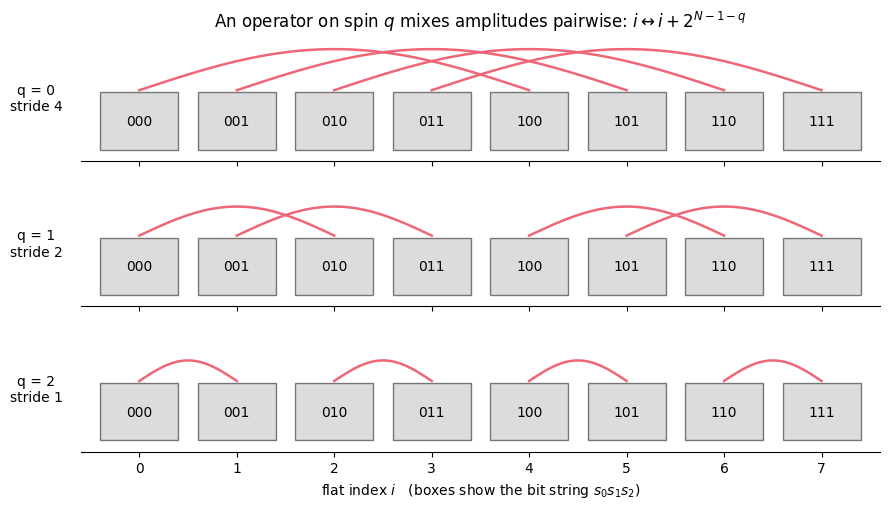

In [7]:
# ==============================================================================
# STEP 3: the same operation as an explicit (slow!) Python loop over the flat vector
# ==============================================================================
def apply_one_site_loop(psi_vec, M, q, N):
    """Eq. (2) written with for-loops on the FLAT vector -- for understanding only.

    MATH   out[i] = M[s_q, 0] * psi[i with bit q = 0]  +  M[s_q, 1] * psi[i with bit q = 1]
    IMPLEMENTATION   bit q of i is (i >> (N-1-q)) & 1;  flipping it changes i by stride = 2^(N-1-q).
    COST   2 multiplications per output amplitude -> 2 * 2^N in total.
    """
    psi_np, M_np = np.asarray(psi_vec), np.asarray(M)
    out = np.zeros_like(psi_np)
    stride = 2 ** (N - 1 - q)
    for i in range(2 ** N):
        s_q = (i >> (N - 1 - q)) & 1              # value of spin q in basis state i
        i0 = i - s_q * stride                     # partner index with spin q = 0
        i1 = i0 + stride                          # partner index with spin q = 1
        out[i] = M_np[s_q, 0] * psi_np[i0] + M_np[s_q, 1] * psi_np[i1]
    return out


for q in range(N):
    err = max_abs_diff(apply_one_site_loop(psi_vec, M, q, N), jnp.einsum(hand_strings[q], M, psi))
    print(f"q={q}: explicit loop vs einsum   max|diff| = {err:.2e}")
    assert err < TOL

# ------------------------------------------------------------------------------
# FIGURE: which amplitudes are mixed by an operator on spin q  (N=3)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(9, 5.2), sharex=True)
for q, ax in enumerate(axes):
    stride = 2 ** (N - 1 - q)
    for i in range(8):
        ax.add_patch(plt.Rectangle((i - 0.4, -0.25), 0.8, 0.5, facecolor="#BBBBBB", alpha=0.5, edgecolor="k"))
        ax.text(i, 0, format(i, "03b"), ha="center", va="center", fontsize=10)
    for i in range(8):
        if (i >> (N - 1 - q)) & 1 == 0:                                   # draw each pair once
            xs = np.linspace(i, i + stride, 50)
            ax.plot(xs, 0.27 + 0.18 * stride ** 0.5 * np.sin(np.pi * (xs - i) / stride), color="#EE6677", lw=1.8)
    ax.set_ylim(-0.35, 0.75); ax.set_yticks([]); ax.set_xlim(-0.6, 7.6)
    ax.set_ylabel(f"q = {q}\nstride {stride}", rotation=0, labelpad=32, va="center")
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
axes[-1].set_xticks(range(8)); axes[-1].set_xlabel("flat index $i$   (boxes show the bit string $s_0s_1s_2$)")
axes[0].set_title("An operator on spin $q$ mixes amplitudes pairwise: $i \\leftrightarrow i+2^{N-1-q}$")
plt.tight_layout(); plt.show()

**Reading the figure.** Each arc is one independent $2\times2$ matrix–vector product. An operator on the last spin mixes
neighbouring amplitudes (stride 1); an operator on spin 0 mixes the first half of the vector with the second half (stride 4).
For every $q$ there are $2^{N-1}=4$ arcs — the work does not depend on *where* the operator acts. The einsum performs all
arcs at once, in compiled code; our Python loop does the same arithmetic painfully slowly and is only there to be understood.

> **Physics insight.** "Local operator" has a precise computational meaning: it couples each basis state to only
> $2^k$ others ($k$ = number of spins it touches), not to all $2^N$. A dense matrix stores and multiplies $2^N-2^k$ zeros per row.
> Matrix-free simulation is nothing but refusing to do that.

## 4. Two-site operators

Interactions ($Z_iZ_j$), entangling gates (CNOT) and Trotter factors $e^{-i h_{ij}dt}$ act on **two** spins. They arrive as
$4\times4$ matrices in the basis $|00\rangle,|01\rangle,|10\rangle,|11\rangle$ of the pair. To contract them with two axes of $\psi$
we must first give them two row indices and two column indices.

### 4.1 Reshaping $4\times4\to(2,2,2,2)$: the index convention

Apply Eq. (1) to the pair: the row number is $r=2a_1+a_2$ and the column number is $c=2b_1+b_2$, where $a_1,b_1$ belong to the
**first** spin of the pair and $a_2,b_2$ to the **second**. C-ordered reshape undoes exactly this packing:

$$ U_4[\,2a_1+a_2\,,\;2b_1+b_2\,] \;=\; U[\underbrace{a_1,a_2}_{\text{row = output}},\underbrace{b_1,b_2}_{\text{column = input}}] ,\qquad \texttt{U = U4.reshape(2,2,2,2)} . $$

* indices 0,1 of the rank-4 tensor = **outputs** (row) of first and second spin; indices 2,3 = **inputs** (column) of first and second spin;
* the "first" spin is the **left factor of the Kronecker product**: for $U_4=M\otimes K$ we have
  $(M\otimes K)[2a_1+a_2,2b_1+b_2]=M[a_1,b_1]\,K[a_2,b_2]$, hence $U[a_1,a_2,b_1,b_2]=M[a_1,b_1]K[a_2,b_2]$.

Let us check both statements numerically, and look at the CNOT gate through these glasses.

In [8]:
# ==============================================================================
# STEP 4: a 4x4 matrix as a rank-4 tensor U[a1, a2, b1, b2]
# ==============================================================================
k_K, key = jax.random.split(key)
K = random_matrix(k_K, 2)

U4 = jnp.kron(M, K)                        # product operator "M on the first spin, K on the second"
U = U4.reshape(2, 2, 2, 2)                 # U[a1, a2, b1, b2]

# (i) element-by-element: U[a1,a2,b1,b2] == M[a1,b1] * K[a2,b2]
for a1, a2, b1, b2 in np.ndindex(2, 2, 2, 2):
    assert abs(U[a1, a2, b1, b2] - M[a1, b1] * K[a2, b2]) < TOL
    assert abs(U[a1, a2, b1, b2] - U4[2 * a1 + a2, 2 * b1 + b2]) < TOL
# (ii) the same statement as ONE einsum (the Kronecker product of notebook 02: "ab,cd->acbd" + reshape)
err = max_abs_diff(jnp.einsum("ac,bd->abcd", M, K), U)
print(f"kron(M,K).reshape(2,2,2,2) == einsum('ac,bd->abcd', M, K):  max|diff| = {err:.2e}")
assert err < TOL

# (iii) CNOT: first spin = control, second = target.
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
C = CNOT.reshape(2, 2, 2, 2)
print("\nCNOT[a1=0, :, b1=0, :]  (control stays 0) =\n", np.asarray(C[0, :, 0, :].real))
print("CNOT[a1=1, :, b1=1, :]  (control stays 1) =\n", np.asarray(C[1, :, 1, :].real))
print("CNOT[a1=0, :, b1=1, :]  (control flips)   =\n", np.asarray(C[0, :, 1, :].real))

kron(M,K).reshape(2,2,2,2) == einsum('ac,bd->abcd', M, K):  max|diff| = 0.00e+00

CNOT[a1=0, :, b1=0, :]  (control stays 0) =
 [[1. 0.]
 [0. 1.]]
CNOT[a1=1, :, b1=1, :]  (control stays 1) =
 [[0. 1.]
 [1. 0.]]
CNOT[a1=0, :, b1=1, :]  (control flips)   =
 [[0. 0.]
 [0. 0.]]


The slices read like the definition of the gate: if the control (first spin) is $0$ the target sees the identity, if it is
$1$ the target sees $X$, and there is no element that changes the control. The rank-4 form makes the *roles* of the four
indices visible, which the flat $4\times4$ table hides.

### 4.2 The contraction, and three hand-written strings for $N=4$

Repeating the derivation of §3.1 with two non-trivial factors gives, for an operator acting on spins $(q_1,q_2)$,

$$ \boxed{\;\psi'[\dots,a_1,\dots,a_2,\dots]\;=\;\sum_{b_1,b_2}U[a_1,a_2,b_1,b_2]\;\psi[\dots,b_1,\dots,b_2,\dots]\;} \tag{3} $$

where $a_1,b_1$ sit on axis $q_1$ and $a_2,b_2$ on axis $q_2$. Nothing in Eq. (3) requires the two axes to be adjacent.
For $N=4$ with axes `a b c d`, and the same capital-letter mnemonic:

| case | $(q_1,q_2)$ | einsum string | comment |
|---|---|---|---|
| neighbours | $(1,2)$ | `"BCbc,abcd->aBCd"` | $U$ carries (new $q_1$, new $q_2$, old $q_1$, old $q_2$) |
| distant | $(0,3)$ | `"ADad,abcd->AbcD"` | same cost — no SWAP gates, no identities in between |
| reversed | $(2,0)$ | `"CAca,abcd->AbCd"` | first spin of $U$ is site 2, second is site 0 |

Look carefully at the third row. The **output is always written in the axis order of $\psi$** (`AbCd`: axis 0 first) — the state
tensor never changes its layout. What changes is the order of letters *on the operator*: its first row/column indices are wired
to axis 2 (`C`,`c`), its second ones to axis 0 (`A`,`a`). The list `(q1, q2)` is thus a *wiring instruction*: "connect the first
spin of $U$ to site $q_1$ and the second to site $q_2$".

### 4.3 An independent dense reference for two-site operators

To test the strings we need the dense $2^N\times2^N$ matrix of "$U_4$ acting on sites $(q_1,q_2)$" built **without** any einsum
on the state. For neighbours $(j,j+1)$ notebook 03 gave us `two_site_operator(h2, j, N)` $=\mathbb 1\otimes h_2\otimes\mathbb 1$, but that does not cover distant or
reversed pairs. For a product operator $M\otimes K$ this is `site_operator(M,q1) @ site_operator(K,q2)`. A general $U_4$ is not a
product, but it is a **sum** of products: the 16 matrices $\sigma^\alpha\otimes\sigma^\beta$ ($\sigma^0=\mathbb 1$, $\sigma^{1,2,3}=X,Y,Z$)
form an orthogonal basis of all $4\times4$ matrices with respect to the trace inner product,
$\mathrm{Tr}[(\sigma^\alpha\otimes\sigma^\beta)^\dagger(\sigma^\gamma\otimes\sigma^\delta)]=4\,\delta_{\alpha\gamma}\delta_{\beta\delta}$, so

$$ U_4=\sum_{\alpha,\beta=0}^{3}c_{\alpha\beta}\,\sigma^\alpha\otimes\sigma^\beta,\qquad c_{\alpha\beta}=\tfrac14\mathrm{Tr}\big[(\sigma^\alpha\otimes\sigma^\beta)\,U_4\big]
\quad\Longrightarrow\quad U_{(q_1,q_2)}=\sum_{\alpha\beta}c_{\alpha\beta}\;\sigma^\alpha_{q_1}\sigma^\beta_{q_2}. $$

(Pauli matrices are Hermitian, so the dagger can be dropped.) This uses only `kron` chains — exactly the technology of notebook 03.

In [9]:
# ==============================================================================
# STEP 5: dense reference for a two-site operator on ARBITRARY sites (validation only)
# ==============================================================================
PAULIS = [I2, X, Y, Z]


def two_site_operator_any(U4, q1, q2, N):
    """Dense 2^N x 2^N matrix of the 4x4 operator U4 acting on sites (q1, q2); q1 = FIRST spin of U4.

    MATH   U4 = sum_{al,be} c[al,be] sigma^al (x) sigma^be,   c[al,be] = Tr[(sigma^al (x) sigma^be) U4] / 4
           U_(q1,q2) = sum_{al,be} c[al,be] * site_operator(sigma^al, q1) @ site_operator(sigma^be, q2)
    Works for neighbours, distant sites and q1 > q2 alike.   COST  O(4^N): VALIDATION ONLY.
    """
    ops1 = [site_operator(P, q1, N) for P in PAULIS]          # sigma^al on site q1 (dense kron chains)
    ops2 = [site_operator(P, q2, N) for P in PAULIS]          # sigma^be on site q2
    dense = jnp.zeros((2 ** N, 2 ** N), dtype=CDTYPE)
    for al, Pa in enumerate(PAULIS):
        for be, Pb in enumerate(PAULIS):
            c = jnp.trace(jnp.kron(Pa, Pb) @ U4) / 4.0        # expansion coefficient c[al,be]
            dense = dense + c * (ops1[al] @ ops2[be])
    return dense


# sanity check of the reference itself: on neighbours (q, q+1) it must equal 1 x ... x U4 x ... x 1
k_U, key = jax.random.split(key)
U4 = random_matrix(k_U, 4)                       # generic (non-product, non-symmetric) two-site operator
ref = two_site_operator(U4, 1, 4)                # kron(1, U4, 1): the neighbour construction of notebook 03
err = max_abs_diff(two_site_operator_any(U4, 1, 2, 4), ref)
print(f"Pauli-decomposition reference vs kron(1, U4, 1) on sites (1,2):  max|diff| = {err:.2e}")
assert err < TOL

Pauli-decomposition reference vs kron(1, U4, 1) on sites (1,2):  max|diff| = 2.48e-16


In [10]:
# ==============================================================================
# STEP 6: two-site operator on N=4 spins -- three hand-written strings vs dense reference
# ==============================================================================
N = 4
k_psi, key = jax.random.split(key)
psi_vec = random_state(k_psi, N)
psi = psi_vec.reshape((2,) * N)
U = U4.reshape(2, 2, 2, 2)                       # random NON-symmetric 4x4 operator -> U[a1,a2,b1,b2]

hand_strings_2 = {(1, 2): "BCbc,abcd->aBCd",     # neighbours
                  (0, 3): "ADad,abcd->AbcD",     # distant sites
                  (2, 0): "CAca,abcd->AbCd"}     # reversed order: first spin of U = site 2, second = site 0

for (q1, q2), sub in hand_strings_2.items():
    out_tensor = jnp.einsum(sub, U, psi)
    out_dense = two_site_operator_any(U4, q1, q2, N) @ psi_vec
    err = max_abs_diff(out_tensor.reshape(-1), out_dense)
    print(f"sites ({q1},{q2}):  einsum('{sub}')  vs dense   max|diff| = {err:.2e}")
    assert err < TOL

# The order matters for a non-symmetric operator: (2,0) and (0,2) are DIFFERENT operators ...
out_20 = jnp.einsum("CAca,abcd->AbCd", U, psi)
out_02 = jnp.einsum("ACac,abcd->AbCd", U, psi)
print(f"\n| U on (2,0) - U on (0,2) |_max = {max_abs_diff(out_20, out_02):.3f}   (not small: different operators!)")
# ... related by exchanging the roles of the two spins in U:  U[a1,a2,b1,b2] -> U[a2,a1,b2,b1]  (= SWAP U4 SWAP)
U_swapped = jnp.transpose(U, (1, 0, 3, 2))
err = max_abs_diff(out_20, jnp.einsum("ACac,abcd->AbCd", U_swapped, psi))
print(f"| U on (2,0) - (SWAP U SWAP) on (0,2) |_max = {err:.2e}")
assert err < TOL

# A concrete example: CNOT with control = site 2, target = site 0, acting on |0010> must give |1010>
basis_0010 = jnp.zeros((2,) * N, dtype=CDTYPE).at[0, 0, 1, 0].set(1.0)
out = jnp.einsum("CAca,abcd->AbCd", CNOT.reshape(2, 2, 2, 2), basis_0010)
print("\nCNOT(control=2, target=0)|0010> has its only non-zero amplitude at index", tuple(int(x) for x in jnp.argwhere(jnp.abs(out) > 0.5)[0]))
assert abs(out[1, 0, 1, 0] - 1.0) < TOL

sites (1,2):  einsum('BCbc,abcd->aBCd')  vs dense   max|diff| = 2.48e-16
sites (0,3):  einsum('ADad,abcd->AbcD')  vs dense   max|diff| = 2.48e-16
sites (2,0):  einsum('CAca,abcd->AbCd')  vs dense   max|diff| = 2.22e-16

| U on (2,0) - U on (0,2) |_max = 2.041   (not small: different operators!)
| U on (2,0) - (SWAP U SWAP) on (0,2) |_max = 0.00e+00



CNOT(control=2, target=0)|0010> has its only non-zero amplitude at index (1, 0, 1, 0)


All three strings reproduce the dense reference to round-off. The experiment with the order shows that $(2,0)$ and
$(0,2)$ differ by an $O(1)$ amount for a generic $U_4$ and coincide once the operator's own two spins are exchanged
($U[a_1,a_2,b_1,b_2]\to U[a_2,a_1,b_2,b_1]$, i.e. $\mathrm{SWAP}\,U_4\,\mathrm{SWAP}$). For *symmetric* operators such as
$Z\otimes Z$ or the Heisenberg coupling the order is irrelevant; for CNOT it decides which spin is the control.

> **Common pitfall.** Writing the output as `"...->CbAd"` for the reversed pair. The output labels must follow the axis order of
> $\psi$; otherwise you silently *permute the spins* of your state in addition to applying the gate. Rule of thumb: take the
> string of $\psi$ and **replace, in place**, each target letter by its new letter.

> **Physics insight.** A distant pair costs exactly as much as a neighbouring pair. Long-range interactions (dipolar
> $1/r^3$ couplings of Rydberg atoms, all-to-all couplings of trapped ions) are therefore no harder for a state-vector
> simulator than nearest-neighbour ones — in contrast to matrix-product-state methods ([notebook 18](../ch07_tensor_networks/18_mps_tebd.ipynb), Chapter 7), which love locality in space.

## 5. The general `apply_gate`: building the string by program

Writing strings by hand does not scale. Following the recipe of §4.2 we now *generate* them for any number of spins $n$ and any
tuple of targets (notebook 02 showed how einsum strings can be assembled with ordinary Python string operations). Four lines:

1. `inp`: label the axes of $\psi$ with the first $n$ letters of the alphabet;
2. `new`: take the next $k$ **unused** letters — one fresh (output) label per target;
3. `out`: copy `inp` and replace, in place, the letter of each target by its fresh letter;
4. operator labels = (fresh letters in target order) + (old letters in target order) — the pattern $U[a_1,a_2,b_1,b_2]$ of Eq. (3).

The Configuration cell defined `_LETTERS = string.ascii_letters` (`a…zA…Z`, 52 labels). Instead of "capital = new" (which
runs out of steam when $n>26$) the program simply takes the *next free* letters; names of summation indices are arbitrary.

In [11]:
# ==============================================================================
# STEP 7: programmatic construction of the einsum string, line by line
# ==============================================================================
def gate_einsum_string(n, qubits, verbose=False):
    """Einsum string for a k-site operator acting on the axes `qubits` of a rank-n tensor.

    MATH   psi'[.., a_1, .., a_k, ..] = sum_{b_1..b_k} U[a_1..a_k, b_1..b_k] psi[.., b_1, .., b_k, ..]      (Eq. 3)
    IMPLEMENTATION   pure Python string manipulation; `qubits` are ordinary ints (known before any JAX tracing).
    """
    k = len(qubits)
    inp = list(_LETTERS[:n])                          # 1. labels of psi's axes:            ['a','b','c',...]
    new = _LETTERS[n:n + k]                           # 2. k fresh labels for the outputs: the letters right after inp
    out = inp.copy()                                  # 3. output = input ...
    for a, q in zip(new, qubits):
        out[q] = a                                    #    ... with target letters replaced IN PLACE
    op = "".join(new) + "".join(inp[q] for q in qubits)   # 4. U[new_1..new_k, old_1..old_k]
    sub = f"{op},{''.join(inp)}->{''.join(out)}"
    if verbose:
        print(f"  n={n}, qubits={tuple(qubits)}")
        print(f"    1. inp = {''.join(inp)}")
        print(f"    2. new = {new}")
        print(f"    3. out = {''.join(out)}")
        print(f"    4. op  = {op}")
        print(f"    => '{sub}'")
    return sub


for n, qubits in [(3, (1,)), (4, (1, 2)), (4, (0, 3)), (4, (2, 0)), (6, (4, 1, 3))]:
    gate_einsum_string(n, qubits, verbose=True)

  n=3, qubits=(1,)
    1. inp = abc
    2. new = d
    3. out = adc
    4. op  = db
    => 'db,abc->adc'
  n=4, qubits=(1, 2)
    1. inp = abcd
    2. new = ef
    3. out = aefd
    4. op  = efbc
    => 'efbc,abcd->aefd'
  n=4, qubits=(0, 3)
    1. inp = abcd
    2. new = ef
    3. out = ebcf
    4. op  = efad
    => 'efad,abcd->ebcf'
  n=4, qubits=(2, 0)
    1. inp = abcd
    2. new = ef
    3. out = fbed
    4. op  = efca
    => 'efca,abcd->fbed'
  n=6, qubits=(4, 1, 3)
    1. inp = abcdef
    2. new = ghi
    3. out = ahcigf
    4. op  = ghiebd
    => 'ghiebd,abcdef->ahcigf'


Compare with the hand-written strings: for $n=4$, targets $(2,0)$, the program gives `"efca,abcd->fbed"` — the same wiring as our
`"CAca,abcd->AbCd"` with the summation-free letters renamed (`C→e`, `A→f`). The last example is a **three-site** operator on
sites $(4,1,3)$ of six spins: the recipe is not limited to $k\le2$.

The function below is a first version of the gate routine. Two details deserve attention:

* the operator may be passed as a $2^k\times2^k$ matrix; we reshape it to $(2,)\times 2k$ inside (§4.1);
* `qubits` are **static Python integers**: they determine the *string*, i.e. the structure of the computation, and must be
  known when JAX traces the function. The state and the matrix entries are ordinary (traced) arrays.

In [12]:
# ==============================================================================
# STEP 8: first version of the general gate routine + systematic validation
# ==============================================================================
def apply_gate_v0(psi, U, qubits):
    """Apply the 2^k x 2^k operator U to the axes `qubits` of the rank-n tensor psi (first version).

    MATH   Eq. (3);  U is reshaped to U[a_1..a_k, b_1..b_k], first listed qubit = most significant bit of U.
    COST   O(2^k 2^n) time, O(2^n) memory.
    """
    k = len(qubits)
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))
    return jnp.einsum(gate_einsum_string(psi.ndim, qubits), U, psi)


# --- exhaustive test on N=5: every site, every ORDERED pair (neighbours, distant, reversed) ---------------------------
N = 5
k_psi, key = jax.random.split(key)
psi_vec = random_state(k_psi, N)
psi = psi_vec.reshape((2,) * N)

worst_1 = max(max_abs_diff(apply_gate_v0(psi, M, (q,)).reshape(-1), site_operator(M, q, N) @ psi_vec) for q in range(N))
worst_2 = max(max_abs_diff(apply_gate_v0(psi, U4, (q1, q2)).reshape(-1), two_site_operator_any(U4, q1, q2, N) @ psi_vec)
              for q1 in range(N) for q2 in range(N) if q1 != q2)
print(f"one-site operator,  all {N} sites            : worst max|diff| = {worst_1:.2e}")
print(f"two-site operator,  all {N * (N - 1)} ordered pairs   : worst max|diff| = {worst_2:.2e}")
assert worst_1 < TOL and worst_2 < TOL

# --- a three-site operator on the contiguous block (1,2,3): dense reference is 1 (x) U8 (x) 1 -------------------------
k_U8, key = jax.random.split(key)
U8 = random_matrix(k_U8, 8)
ref = jnp.kron(jnp.kron(I2, U8), I2) @ psi_vec
err = max_abs_diff(apply_gate_v0(psi, U8, (1, 2, 3)).reshape(-1), ref)
print(f"three-site operator on (1,2,3), contiguous   : max|diff| = {err:.2e}")
assert err < TOL

# --- and a NON-contiguous, NON-ordered placement (3,0,2).  A dense reference for a GENERAL 8x8 operator would need the
#     three-site version of the Pauli trick (Exercise 4); for a PRODUCT operator A (x) B (x) C it is simply the product of
#     three Kronecker chains -- still no einsum anywhere on the reference side ---------------------------------------------
k_A, k_B, k_C, key = jax.random.split(key, 4)
A3, B3, C3 = (random_matrix(k, 2) for k in (k_A, k_B, k_C))
U8_prod = jnp.kron(jnp.kron(A3, B3), C3)                    # first spin of U8_prod -> site 3, second -> site 0, third -> site 2
ref_prod = site_operator(A3, 3, N) @ site_operator(B3, 0, N) @ site_operator(C3, 2, N) @ psi_vec
err_prod = max_abs_diff(apply_gate_v0(psi, U8_prod, (3, 0, 2)).reshape(-1), ref_prod)
print(f"three-site product operator on (3,0,2)       : max|diff| = {err_prod:.2e}")
assert err_prod < TOL
print("CHECKPOINT passed: the generated strings are correct for k = 1, 2, 3.")

one-site operator,  all 5 sites            : worst max|diff| = 0.00e+00
two-site operator,  all 20 ordered pairs   : worst max|diff| = 4.45e-16


three-site operator on (1,2,3), contiguous   : max|diff| = 0.00e+00
three-site product operator on (3,0,2)       : max|diff| = 4.44e-16
CHECKPOINT passed: the generated strings are correct for k = 1, 2, 3.


Every one of the 5 single-site and 20 ordered two-site placements agrees with the dense Kronecker construction to
$\sim10^{-16}$, and so do a three-site operator on a contiguous block and a three-site *product* operator wired to the
scrambled sites $(3,0,2)$ — the case that actually exercises the reordering logic. This is the level of evidence you should
demand from any simulator primitive before building on it. (A dense reference for a *general* three-site operator on
scrambled sites needs the $k$-fold Pauli expansion of §4.3; that is Exercise 4.)

### 5.1 The production version

Below is the function as it lives in the engine of this course — the cell is inserted verbatim from the engine file and is what
every later notebook reuses in its "Engine recap". It is our `apply_gate_v0` with the string construction inlined. Read the
docstring: it summarises this whole notebook. (Its illustrative strings use capital letters for readability; the generated ones use
the next free lowercase letters, as we saw.)

In [13]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


In [14]:
# ==============================================================================
# CHECKPOINT: engine apply_gate == our step-by-step version;   jit with static qubits;   vmap over a batch
# ==============================================================================
for qubits, op in [((3,), M), ((1, 2), U4), ((4, 0), U4), ((3, 0, 2), U8)]:
    err = max_abs_diff(apply_gate(psi, op, qubits), apply_gate_v0(psi, op, qubits))
    print(f"apply_gate vs apply_gate_v0, qubits={qubits}:  max|diff| = {err:.2e}")
    assert err < TOL

# --- jit: the qubits are baked into the compiled program (closure); psi and U stay run-time inputs ---------------------
gate_on_40 = jax.jit(lambda psi, U: apply_gate(psi, U, (4, 0)))
err = max_abs_diff(gate_on_40(psi, U4), apply_gate(psi, U4, (4, 0)))
print(f"\njit-compiled gate on (4,0) vs eager: max|diff| = {err:.2e}")
assert err < TOL

# --- equivalent: tell jit explicitly which argument is static (must be hashable -> a tuple, not a list) ---------------
apply_gate_jit = jax.jit(apply_gate, static_argnums=2)
assert max_abs_diff(apply_gate_jit(psi, U4, (4, 0)), gate_on_40(psi, U4)) < TOL

# --- vmap: the same gate on a BATCH of 7 states, without a Python loop -------------------------------------------------
k_batch, key = jax.random.split(key)
batch = jax.vmap(lambda k: random_state(k, N).reshape((2,) * N))(jax.random.split(k_batch, 7))     # shape (7, 2,2,2,2,2)
batch_out = jax.vmap(lambda p: apply_gate(p, U4, (4, 0)))(batch)
err = max(max_abs_diff(batch_out[i], apply_gate(batch[i], U4, (4, 0))) for i in range(7))
print(f"vmap over a batch of 7 states vs a Python loop: max|diff| = {err:.2e}   (batch shape {batch_out.shape})")
assert err < TOL

apply_gate vs apply_gate_v0, qubits=(3,):  max|diff| = 0.00e+00
apply_gate vs apply_gate_v0, qubits=(1, 2):  max|diff| = 0.00e+00
apply_gate vs apply_gate_v0, qubits=(4, 0):  max|diff| = 0.00e+00
apply_gate vs apply_gate_v0, qubits=(3, 0, 2):  max|diff| = 0.00e+00

jit-compiled gate on (4,0) vs eager: max|diff| = 0.00e+00


vmap over a batch of 7 states vs a Python loop: max|diff| = 0.00e+00   (batch shape (7, 2, 2, 2, 2, 2))


> **JAX practice.** `jax.jit` traces a function once with abstract arrays and compiles the recorded operations with XLA
> ([notebook 01](../ch01_computational_toolbox/01_jax_from_scratch.ipynb)). Anything that decides *which* operations are recorded — here the einsum string, hence
> `qubits` — must be a concrete Python value at trace time. Either close over it (`lambda psi, U: apply_gate(psi, U, (4, 0))`) or
> declare it static (`static_argnums`). A different tuple of qubits triggers a new compilation; a different state or matrix does not.
> `jax.vmap` adds a batch axis to every einsum automatically: we will use it in §7 to build a dense matrix from its action, and
> later in the course for trajectories and parameter sweeps.

> **Numerical practice.** The string needs one letter per axis plus one fresh letter per target, i.e. $n+k\le52$. With 52 letters the routine therefore handles states of up to $N=52-k$ spins, far beyond what fits in memory
> ($N\approx30$ on a large workstation). For density *tensors*, which have $2N$ axes (notebook 07), the same counting gives $2N+k\le52$, i.e. $N\le26-k/2$ — also far beyond reach.

## 6. Alternative implementations and a benchmark

`einsum` is not the only way to implement Eq. (2)/(3). Two classical alternatives — you will meet them in other codes — are:

**(a) reshape to `(left, 2, right)` and use `matmul`.** Group all axes before $q$ into one index of size $2^q$ and all axes after it
into one of size $2^{N-q-1}$. Eq. (2) becomes a *batched* matrix product, `U @ psi3` with `psi3.shape = (left, 2, right)`:
for each value of `left`, the $2\times$`right` matrix is multiplied by $U$ from the left. No transposition needed — but this only works
directly for one site (or a block of adjacent sites).

**(b) `tensordot` + `moveaxis`.** `jnp.tensordot(U, psi, axes=(input axes of U, target axes of psi))` performs the contraction of
Eq. (3) but puts the $k$ new axes **first**; `jnp.moveaxis` then brings them back to positions `qubits`. This is the
"transpose – multiply – transpose back" pattern that works for any set of sites.

**(c) transpose + reshape + one `matmul`.** Bring the target axes to the front, flatten to a $(2^k, 2^{N-k})$ matrix, multiply by the
$2^k\times2^k$ matrix, undo. Mathematically the same as (b), written with elementary operations.

And of course **(d) the dense textbook approach**: build `site_operator` ($4^N$ numbers) and multiply.

In [15]:
# ==============================================================================
# STEP 9: alternative implementations of the same contraction
# ==============================================================================
def apply_gate_block(psi, U, q):
    """(a) ONE-site operator via reshape to (left, 2, right) and a batched matmul.

    MATH   out[l, a, r] = sum_b U[a, b] psi[l, b, r],   l = (s_0..s_{q-1}),  r = (s_{q+1}..s_{N-1})
    IMPLEMENTATION   jnp.matmul broadcasts U (2,2) over the leading batch index l:  (2,2) @ (left,2,right).
    """
    n = psi.ndim
    psi3 = psi.reshape(2 ** q, 2, 2 ** (n - q - 1))
    return jnp.matmul(U.astype(psi.dtype), psi3).reshape((2,) * n)


def apply_gate_tensordot(psi, U, qubits):
    """(b) k-site operator via tensordot + moveaxis.

    IMPLEMENTATION   tensordot sums the INPUT axes (k..2k-1) of U against the axes `qubits` of psi; the result has the
    k OUTPUT axes of U first, followed by the untouched axes of psi in their original order; moveaxis puts output axis j
    back to position qubits[j].
    """
    k = len(qubits)
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))
    out = jnp.tensordot(U, psi, axes=(list(range(k, 2 * k)), list(qubits)))
    return jnp.moveaxis(out, list(range(k)), list(qubits))


def apply_gate_matmul(psi, U, qubits):
    """(c) k-site operator via explicit transpose -> (2^k, 2^(n-k)) matrix -> matmul -> inverse transpose."""
    k, n = len(qubits), psi.ndim
    perm = list(qubits) + [a for a in range(n) if a not in qubits]       # targets first, spectators after
    mat = jnp.transpose(psi, perm).reshape(2 ** k, -1)
    mat = jnp.asarray(U, dtype=psi.dtype) @ mat
    inverse = [perm.index(a) for a in range(n)]                          # where did axis a go?
    return jnp.transpose(mat.reshape((2,) * n), inverse)


# --- all variants must agree with apply_gate (N=5 state from above) ---------------------------------------------------
for q in range(N):
    assert max_abs_diff(apply_gate_block(psi, M, q), apply_gate(psi, M, (q,))) < TOL
for qubits, op in [((2,), M), ((1, 2), U4), ((0, 4), U4), ((3, 1), U4), ((3, 0, 2), U8)]:
    e_td = max_abs_diff(apply_gate_tensordot(psi, op, qubits), apply_gate(psi, op, qubits))
    e_mm = max_abs_diff(apply_gate_matmul(psi, op, qubits), apply_gate(psi, op, qubits))
    print(f"qubits={str(qubits):10s}  tensordot: {e_td:.2e}   transpose+matmul: {e_mm:.2e}")
    assert e_td < TOL and e_mm < TOL
print("CHECKPOINT passed: four implementations, one result.")

qubits=(2,)        tensordot: 0.00e+00   transpose+matmul: 0.00e+00
qubits=(1, 2)      tensordot: 0.00e+00   transpose+matmul: 0.00e+00
qubits=(0, 4)      tensordot: 0.00e+00   transpose+matmul: 0.00e+00


qubits=(3, 1)      tensordot: 2.48e-16   transpose+matmul: 2.48e-16
qubits=(3, 0, 2)   tensordot: 2.48e-16   transpose+matmul: 2.48e-16
CHECKPOINT passed: four implementations, one result.


### 6.1 Benchmark protocol

Timing JAX code requires some care (notebook 01):

* JAX dispatches work **asynchronously** — we must call `jax.block_until_ready` before stopping the clock;
* the **first call** of a jitted function includes tracing and XLA compilation; we report it separately ("first call") from the
  steady-state run time;
* run times fluctuate (other processes, caches, CPU frequency) — and noise only ever makes a run *slower* — so we repeat each call at least 5 times
  (fast calls many more times) and report the **minimum**;
* every variant is wrapped in `jax.jit` (with the qubits closed over), because that is how we will use it; for comparison we also time
  `apply_gate` *without* jit, where every call pays Python/dispatch overhead;
* the dense operator is built once (timed separately) and only the product `O @ psi_vec` enters the run time; we stop at $N=12$,
  where the matrix already occupies 268 MB.

We apply a one-site operator to the middle spin $q=N/2$ and a two-site operator to the distant pair $(1,N-2)$.

> **Numerical practice.** Absolute timings depend on the machine, on the backend (CPU/GPU) and on whatever else the computer
> is doing. Conclusions should rest on **scaling with $N$ and ratios between methods**, which are robust.

In [16]:
# ==============================================================================
# STEP 10: benchmark -- time (first call vs steady state) and memory as functions of N
# ==============================================================================
def time_fn(fn, *args, min_reps=5, min_time=0.2, max_reps=500):
    """Return (first_call_seconds, best_steady_state_seconds) of fn(*args), blocking until the result is ready.

    The first call of a jitted function = tracing + XLA compilation + one execution.  Afterwards the call is repeated
    at least `min_reps` times AND for at least `min_time` seconds (fast functions get many repetitions); the MINIMUM
    is reported: noise from other processes only ever makes a run slower, so the minimum is the most robust estimate.
    """
    t0 = time.perf_counter(); jax.block_until_ready(fn(*args)); first = time.perf_counter() - t0
    best, reps, t_start = np.inf, 0, time.perf_counter()
    while reps < min_reps or (time.perf_counter() - t_start < min_time and reps < max_reps):
        t0 = time.perf_counter(); jax.block_until_ready(fn(*args)); best = min(best, time.perf_counter() - t0)
        reps += 1
    return first, best


# ------------------------------------------------------------------------------ PARAMETERS
N_LIST_FREE = [4, 6, 8, 10, 12, 14, 16, 18, 20, 22]      # matrix-free variants
N_MAX_DENSE = 12                                         # dense operator: 16 * 4^N bytes (268 MB at N=12, double precision)
BYTES = np.dtype(CDTYPE).itemsize                        # bytes per complex number: 16 (double) or 8 (single precision)
# ------------------------------------------------------------------------------
k_bench, key = jax.random.split(key)
bench = {}                                               # bench[name][N] = (first_call, best)
dense_build, dense_bytes, state_bytes = {}, {}, {}

for n in N_LIST_FREE:
    q_mid, pair = n // 2, (1, n - 2)
    state_vec = random_state(jax.random.fold_in(k_bench, n), n)
    state = state_vec.reshape((2,) * n)
    state_bytes[n] = state.nbytes
    variants = {
        "einsum (apply_gate), 1 site":   (jax.jit(lambda p, U: apply_gate(p, U, (q_mid,))), M),
        "reshape (left,2,right) + matmul, 1 site": (jax.jit(lambda p, U: apply_gate_block(p, U, q_mid)), M),
        "tensordot + moveaxis, 1 site":  (jax.jit(lambda p, U: apply_gate_tensordot(p, U, (q_mid,))), M),
        "einsum, no jit, 1 site":        (lambda p, U: apply_gate(p, U, (q_mid,)), M),
        "einsum (apply_gate), 2 sites":  (jax.jit(lambda p, U: apply_gate(p, U, pair)), U4),
        "tensordot + moveaxis, 2 sites": (jax.jit(lambda p, U: apply_gate_tensordot(p, U, pair)), U4),
        "transpose + matmul, 2 sites":   (jax.jit(lambda p, U: apply_gate_matmul(p, U, pair)), U4),
    }
    for name, (fn, op) in variants.items():
        bench.setdefault(name, {})[n] = time_fn(fn, state, op)
    if n <= N_MAX_DENSE:                                 # the textbook way: build the 2^N x 2^N matrix, then multiply
        t0 = time.perf_counter(); O_dense = jax.block_until_ready(site_operator(M, q_mid, n)); dense_build[n] = time.perf_counter() - t0
        dense_bytes[n] = O_dense.nbytes
        bench.setdefault("dense kron matrix @ vector, 1 site", {})[n] = time_fn(jax.jit(lambda O, v: O @ v), O_dense, state_vec)
        del O_dense

# ------------------------------------------------------------------------------ table
print(f"backend: {jax.default_backend()}     (times in milliseconds; 'first' = compile + run, 'run' = best of >= 5 repetitions)\n")
cols = ["einsum (apply_gate), 1 site", "reshape (left,2,right) + matmul, 1 site", "tensordot + moveaxis, 1 site",
        "einsum, no jit, 1 site", "dense kron matrix @ vector, 1 site"]
short = ["einsum+jit", "block matmul", "tensordot", "einsum no-jit", "DENSE matvec"]
print("  N | " + " | ".join(f"{s:>21s}" for s in short) + " | dense build")
print("    | " + " | ".join(f"{'first':>10s} {'run':>10s}" for _ in short) + " |")
for n in N_LIST_FREE:
    row = []
    for c in cols:
        row.append(f"{bench[c][n][0] * 1e3:10.1f} {bench[c][n][1] * 1e3:10.3f}" if n in bench[c] else f"{'--':>10s} {'--':>10s}")
    build = f"{dense_build[n] * 1e3:9.1f}" if n in dense_build else "       --"
    print(f" {n:2d} | " + " | ".join(row) + " | " + build)

backend: cpu     (times in milliseconds; 'first' = compile + run, 'run' = best of >= 5 repetitions)

  N |            einsum+jit |          block matmul |             tensordot |         einsum no-jit |          DENSE matvec | dense build
    |      first        run |      first        run |      first        run |      first        run |      first        run |
  4 |       28.1      0.010 |       34.7      0.010 |       30.6      0.009 |       28.8      0.155 |       10.6      0.010 |       0.3
  6 |       34.4      0.010 |       33.3      0.011 |       31.9      0.011 |       32.5      0.153 |       11.2      0.013 |      28.0
  8 |       41.0      0.010 |       36.8      0.011 |       35.7      0.010 |       38.1      0.163 |       11.8      0.052 |      58.7
 10 |       45.9      0.013 |       36.1      0.015 |       35.2      0.016 |       45.5      0.167 |       11.6      0.258 |      59.7
 12 |       49.7      0.025 |       36.5      0.026 |       36.0      0.027 |       51.7   

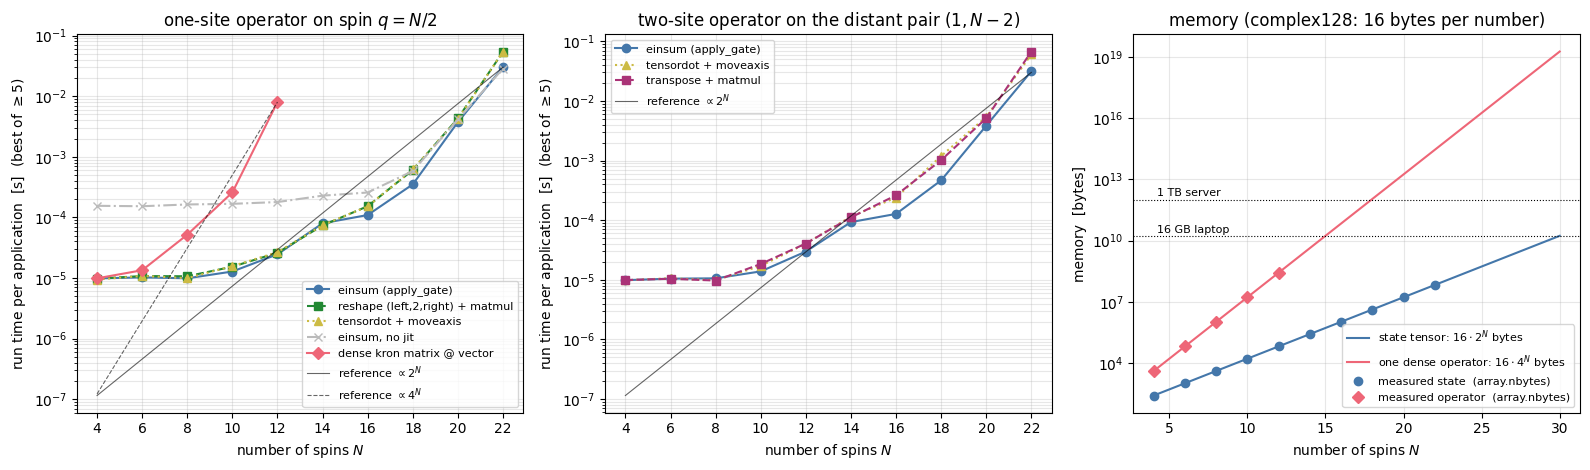

N=12: dense matvec / einsum run time = 325x ;  dense operator memory / state memory = 4096x  ;  building the dense operator took 0.09 s
N=22: one-site einsum 30.1 ms, two-site einsum 31.4 ms on a state of 67 MB; a dense operator would need 281 TB.


In [17]:
# ==============================================================================
# FIGURE: run time and memory versus N
# ==============================================================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.8))
style = {"einsum (apply_gate), 1 site": ("o-", "#4477AA"), "reshape (left,2,right) + matmul, 1 site": ("s--", "#228833"),
         "tensordot + moveaxis, 1 site": ("^:", "#CCBB44"), "einsum, no jit, 1 site": ("x-.", "#BBBBBB"),
         "dense kron matrix @ vector, 1 site": ("D-", "#EE6677"),
         "einsum (apply_gate), 2 sites": ("o-", "#4477AA"), "tensordot + moveaxis, 2 sites": ("^:", "#CCBB44"),
         "transpose + matmul, 2 sites": ("s--", "#AA3377")}
for name, data in bench.items():
    ax = ax1 if "1 site" in name else ax2
    ns = sorted(data)
    ax.semilogy(ns, [data[n][1] for n in ns], style[name][0], color=style[name][1], label=name.replace(", 1 site", "").replace(", 2 sites", ""))
ns = np.array(N_LIST_FREE, dtype=float)
t_ref = bench["einsum (apply_gate), 1 site"][N_LIST_FREE[-1]][1]
for ax in (ax1, ax2):
    ax.semilogy(ns, t_ref * 2.0 ** (ns - ns[-1]), "k-", lw=0.8, alpha=0.6, label=r"reference $\propto 2^N$")
nd = np.array(sorted(dense_build), dtype=float)
t_refd = bench["dense kron matrix @ vector, 1 site"][int(nd[-1])][1]
ax1.semilogy(nd, t_refd * 4.0 ** (nd - nd[-1]), "k--", lw=0.8, alpha=0.6, label=r"reference $\propto 4^N$")
ax1.set_title("one-site operator on spin $q=N/2$"); ax2.set_title("two-site operator on the distant pair $(1, N-2)$")
for ax in (ax1, ax2):
    ax.set_xlabel("number of spins $N$"); ax.set_ylabel("run time per application  [s]  (best of $\\geq5$)")
    ax.set_xticks(N_LIST_FREE); ax.grid(True, which="both", alpha=0.3); ax.legend(fontsize=8)

n_all = np.arange(4, 31)
ax3.semilogy(n_all, BYTES * 2.0 ** n_all, "-", color="#4477AA", label=rf"state tensor: ${BYTES}\cdot 2^N$ bytes")
ax3.semilogy(n_all, BYTES * 4.0 ** n_all, "-", color="#EE6677", label=rf"one dense operator: ${BYTES}\cdot 4^N$ bytes")
ax3.semilogy(list(state_bytes), list(state_bytes.values()), "o", color="#4477AA", label="measured state  (array.nbytes)")
ax3.semilogy(list(dense_bytes), list(dense_bytes.values()), "D", color="#EE6677", label="measured operator  (array.nbytes)")
for gb, lab in [(16, "16 GB laptop"), (1000, "1 TB server")]:
    ax3.axhline(gb * 1e9, color="k", lw=0.8, ls=":"); ax3.text(4.2, gb * 1e9 * 1.5, lab, fontsize=8)
ax3.set_xlabel("number of spins $N$"); ax3.set_ylabel("memory  [bytes]"); ax3.set_title(f"memory ({np.dtype(CDTYPE).name}: {BYTES} bytes per number)")
ax3.grid(True, which="both", alpha=0.3); ax3.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

# ratios quoted in the text below
n_cmp = N_MAX_DENSE
ratio = bench["dense kron matrix @ vector, 1 site"][n_cmp][1] / bench["einsum (apply_gate), 1 site"][n_cmp][1]
print(f"N={n_cmp}: dense matvec / einsum run time = {ratio:.0f}x ;  dense operator memory / state memory = {dense_bytes[n_cmp] / state_bytes[n_cmp]:.0f}x"
      f"  ;  building the dense operator took {dense_build[n_cmp]:.2f} s")
n_big = N_LIST_FREE[-1]
print(f"N={n_big}: one-site einsum {bench['einsum (apply_gate), 1 site'][n_big][1] * 1e3:.1f} ms, two-site einsum "
      f"{bench['einsum (apply_gate), 2 sites'][n_big][1] * 1e3:.1f} ms on a state of {state_bytes[n_big] / 1e6:.0f} MB; "
      f"a dense operator would need {BYTES * 4.0 ** n_big / 1e12:.0f} TB.")

**Reading the benchmark** (absolute numbers are those of the machine that executed this notebook, and of its load at that
moment; rerun to get yours — the *shapes* of the curves are what matters).

* **First call vs run.** For small $N$ the first call of every jitted variant costs a few tenths of a second — entirely tracing and compilation — while
  the steady-state run takes a fraction of a millisecond. Compilation is paid once per (function, qubits, shape); in a time
  evolution with thousands of identical steps it is irrelevant, in a one-off calculation it dominates. Always report them separately.
* **Small $N$ is overhead-dominated.** Up to $N\approx10$–$12$ the run time of the matrix-free variants is flat: the actual arithmetic
  (a few thousand multiplications) is negligible compared with the fixed cost of launching a compiled kernel. The un-jitted einsum
  is roughly an order of magnitude slower there, because each call re-does Python-level work (building the string, dispatching the operation).
* **Large $N$ follows the $2^N$ law.** Beyond the overhead regime all matrix-free curves become parallel to the thin black
  $2^N$ reference line: doubling the Hilbert space doubles the time. (On our machine the last step, $N=20\to22$, is steeper than that: the 67 MB state and its equally
  large output no longer fit into the CPU caches.) The **dense** matrix–vector product follows $4^N$ instead
  (dashed reference): the two families of curves part company already around $N\approx6$–$8$, and by $N=12$ the dense product is slower by more than two orders of magnitude (the exact ratio is printed under the figure) — not counting the time to *build* the
  matrix, nor its memory.
* **The variants are close relatives.** einsum, tensordot and transpose+matmul describe the same contraction, and XLA lowers
  all of them to similar kernels (a transposition plus a small matrix product). Their run times differ by factors of order one, which
  vary with $N$, the target position and the machine; none of them changes the scaling. We use **einsum** throughout the course because
  the *code is the formula*: Eq. (3) and the string `"efca,abcd->fbed"` are the same statement, for any number and order of target sites,
  with nothing to get wrong in axis bookkeeping.
* **Memory** (right panel). A state of $N=22$ spins needs 67 MB; a single dense operator on the same system would need $\sim$280 TB.
  With matrix-free operators the **state itself is the only large object**, and the limit on a 16 GB laptop moves from $N\approx14$ to
  $N\approx 28$–$29$ (remember that the output of a gate is a second array of the same size).

> **JAX practice.** On a GPU the same code runs unchanged (set `DEVICE="gpu"` in the Configuration cell) — rerun this section there. Expect the same two regimes: an
> overhead plateau set by the kernel-launch latency, and the $2^N$ law with a prefactor set mostly by *memory bandwidth*:
> applying a small gate to a large state is **memory-bound** — the processor spends its time moving amplitudes, not multiplying them.

## 7. Matrix-free $H|\psi\rangle$: a Hamiltonian is a list of local terms

### 7.1 The idea

The Hamiltonians of notebook 03 are sums of one- and two-site operators. In Pauli convention the family we use is

$$ H=\sum_{\langle i,j\rangle}\big(J_{xx}X_iX_j+J_{yy}Y_iY_j+J_{zz}Z_iZ_j\big)+\sum_i\big(h_xX_i+h_yY_i+h_zZ_i\big), $$

which contains the Heisenberg/XXZ chains and, for $J_{zz}=-J$, $h_x=-h$ and all other couplings zero, the
**transverse-field Ising model** (TFIM) $H=-J\sum_iZ_iZ_{i+1}-h\sum_iX_i$.

Because matrix–vector multiplication is linear, $H|\psi\rangle=\sum_k h_k|\psi\rangle$, and each $h_k|\psi\rangle$ is one
`apply_gate` call with a Hermitian (non-unitary) $2\times2$ or $4\times4$ matrix. So we do not *store a matrix* at all:

> **the Hamiltonian is a Python list** `[(qubits, small_matrix), ...]`.

For an open chain this list has $N-1$ bond terms and $N$ field terms: $O(N)$ small matrices instead of $4^N$ numbers, and
$H|\psi\rangle$ costs $O(N\,2^N)$. Below are the engine functions that implement this (again inserted verbatim):
`heisenberg_terms` builds the list, `apply_hamiltonian` sums the local actions, `energy` computes
$\langle\psi|H|\psi\rangle=\mathrm{Re}\,\langle\psi|(H\psi)\rangle$ with one `vdot` (which conjugates its first argument), and
`dense_hamiltonian` recovers the full matrix for validation — we discuss it in §7.3.

In [18]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


### 7.2 Validation against the dense Hamiltonian of notebook 03

The reference is built the textbook way, from `site_operator` Kronecker chains. We test a generic member of the family (all
couplings and fields different, so that no term can hide behind a symmetry) and the TFIM.

In [19]:
# ==============================================================================
# STEP 11: H|psi> matrix-free  vs  dense Hamiltonian (kron construction of notebook 03)
# ==============================================================================
def build_hamiltonian_dense(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0):
    """Dense 2^N x 2^N Hamiltonian of the open chain, built from Kronecker products (notebook 03).  VALIDATION ONLY.

    MATH   H = sum_i (Jxx X_i X_{i+1} + Jyy Y_i Y_{i+1} + Jzz Z_i Z_{i+1}) + sum_i (hx X_i + hy Y_i + hz Z_i)
    COST   O(N 8^N) time (products of dense matrices), O(4^N) memory.
    """
    Hd = jnp.zeros((2 ** N, 2 ** N), dtype=CDTYPE)
    for i in range(N - 1):
        for Jc, P in ((Jxx, X), (Jyy, Y), (Jzz, Z)):
            Hd = Hd + Jc * site_operator(P, i, N) @ site_operator(P, i + 1, N)
    for i in range(N):
        for hc, P in ((hx, X), (hy, Y), (hz, Z)):
            Hd = Hd + hc * site_operator(P, i, N)
    return Hd


# ------------------------------------------------------------------------------ PARAMETERS
N = 8
generic = dict(Jxx=1.0, Jyy=0.8, Jzz=-0.6, hx=0.3, hy=-0.2, hz=0.5)      # a generic member of the family
tfim = dict(Jxx=0.0, Jyy=0.0, Jzz=-1.0, hx=-1.0)                         # TFIM with J = h = 1
# ------------------------------------------------------------------------------
k_psi, key = jax.random.split(key)
psi_vec = random_state(k_psi, N)
psi = psi_vec.reshape((2,) * N)

for name, pars in [("generic XYZ + fields", generic), ("TFIM  J=h=1", tfim)]:
    terms = heisenberg_terms(N, **pars)
    H_dense = build_hamiltonian_dense(N, **pars)
    err_Hpsi = max_abs_diff(apply_hamiltonian(terms, psi).reshape(-1), H_dense @ psi_vec)
    E_free = float(energy(terms, psi))
    E_dense = float(jnp.real(jnp.vdot(psi_vec, H_dense @ psi_vec)))
    print(f"{name:22s}: {len(terms):2d} local terms | max|H psi - H_dense psi| = {err_Hpsi:.2e} | "
          f"<H> = {E_free:+.12f} (matrix-free) vs {E_dense:+.12f} (dense)")
    assert err_Hpsi < TOL and abs(E_free - E_dense) < TOL

# Hermiticity of the matrix-free operator:  <phi|H psi> == <H phi|psi>  for random states
k_phi, key = jax.random.split(key)
phi = random_state(k_phi, N).reshape((2,) * N)
terms = heisenberg_terms(N, **generic)
herm = abs(jnp.vdot(phi, apply_hamiltonian(terms, psi)) - jnp.vdot(apply_hamiltonian(terms, phi), psi))
print(f"\nHermiticity check  |<phi|H psi> - <H phi|psi>| = {float(herm):.2e}")
assert herm < TOL

generic XYZ + fields  : 15 local terms | max|H psi - H_dense psi| = 3.33e-16 | <H> = +0.242914167060 (matrix-free) vs +0.242914167060 (dense)
TFIM  J=h=1           : 15 local terms | max|H psi - H_dense psi| = 2.22e-16 | <H> = -0.076983421978 (matrix-free) vs -0.076983421978 (dense)

Hermiticity check  |<phi|H psi> - <H phi|psi>| = 1.24e-16


For both models the matrix-free $H|\psi\rangle$ agrees with the dense product to $\sim10^{-16}$, and the energies agree to all
printed digits. The generic model needs $7+8=15$ small matrices; the dense $256\times256$ matrix has 65 536 entries — and the
gap between these two numbers grows like $4^N/N$. The Hermiticity check is a useful extra: it tests the operator on *two*
random vectors without any reference matrix, so it also works at sizes where no dense reference exists.

### 7.3 From the action back to the matrix: `dense_hamiltonian` with `vmap`

Any linear operator is fully determined by its action on the basis vectors: **column $j$ of $H$ is $H|e_j\rangle$**. The engine's
`dense_hamiltonian` does exactly this:

1. `jnp.eye(2**N)` holds all basis vectors as its rows; reshaped to `(2**N, 2, ..., 2)` it is a *batch* of $2^N$ rank-$N$ tensors;
2. `jax.vmap` maps `apply_hamiltonian` over the batch axis — one batched einsum per term, no Python loop over $j$;
3. row $j$ of the result is $(H e_j)$ flattened, i.e. *column* $j$ of $H$; hence the final transpose.

This inverts the logic of notebook 03: there the matrix was primary and its action derived; now the **action is primary** and the matrix
is an optional by-product which we only build for small $N$, to diagonalise it or to validate something.

In [20]:
# ==============================================================================
# STEP 12: dense_hamiltonian (vmap over basis vectors)  vs  the kron construction;  spectra
# ==============================================================================
N = 8
terms = heisenberg_terms(N, **generic)
t0 = time.perf_counter(); H_vmap = jax.block_until_ready(dense_hamiltonian(terms, N)); t_vmap = time.perf_counter() - t0
t0 = time.perf_counter(); H_kron = jax.block_until_ready(build_hamiltonian_dense(N, **generic)); t_kron = time.perf_counter() - t0

err = max_abs_diff(H_vmap, H_kron)
print(f"dense_hamiltonian (vmap of the matrix-free action) vs kron construction: max|diff| = {err:.2e}")
print(f"   build time: vmap {t_vmap:.2f} s   |   kron chains {t_kron:.2f} s      (N={N}, first call, includes compilation)")
assert err < TOL
assert max_abs_diff(H_vmap, H_vmap.conj().T) < TOL                                   # Hermitian

E_vmap, E_kron = jnp.linalg.eigvalsh(H_vmap), jnp.linalg.eigvalsh(H_kron)
print(f"spectra agree to {max_abs_diff(E_vmap, E_kron):.2e};   ground-state energy E0 = {float(E_vmap[0]):.10f}")
assert max_abs_diff(E_vmap, E_kron) < 1e3 * TOL

dense_hamiltonian (vmap of the matrix-free action) vs kron construction: max|diff| = 0.00e+00
   build time: vmap 0.93 s   |   kron chains 0.03 s      (N=8, first call, includes compilation)


spectra agree to 0.00e+00;   ground-state energy E0 = -8.6097881675


The two matrices are identical to round-off and have the same spectrum. In operation count the route through the matrix-free action is the
cheaper one — $O(N4^N)$ (one $H|e_j\rangle$ per basis vector) against $O(N8^N)$ for products of dense Kronecker chains — but at $N=8$ both build times
printed above are dominated by one-off overheads (compilation of the batched einsums), not by arithmetic; do not read a scaling law into them.

### 7.4 The speed-up of the matrix-free $H|\psi\rangle$

The matrix–vector product is the workhorse of iterative eigensolvers (Lanczos) and of polynomial time-evolution methods
(Chebyshev, Krylov) — all of Chapter 5 — so its cost is what ultimately limits the accessible $N$. We time the TFIM matvec, jitted, with the
list of terms closed over.

In [21]:
# ==============================================================================
# STEP 13: timing H|psi> -- matrix-free (N up to 20) vs dense matrix (N up to 12)
# ==============================================================================
print("   N | #terms |  matrix-free: first call [s]   run [ms] |  dense: build [s]   run [ms] | dense/free")
t_free_H = {}
for n in [6, 8, 10, 12, 14, 16, 18, 20]:
    terms_n = heisenberg_terms(n, **tfim)
    state = random_state(jax.random.fold_in(k_bench, 100 + n), n).reshape((2,) * n)
    matvec = jax.jit(lambda p: apply_hamiltonian(terms_n, p))            # terms are compile-time constants (closure)
    first, best = time_fn(matvec, state)
    t_free_H[n] = best
    line = f"  {n:2d} | {len(terms_n):6d} | {first:28.2f} {best * 1e3:10.3f} |"
    if n <= 12:
        t0 = time.perf_counter(); H_dense = jax.block_until_ready(dense_hamiltonian(terms_n, n)); t_build = time.perf_counter() - t0
        _, best_d = time_fn(jax.jit(lambda Hm, v: Hm @ v), H_dense, state.reshape(-1))
        line += f" {t_build:17.2f} {best_d * 1e3:10.3f} | {best_d / best:9.1f}x"
        del H_dense
    else:
        line += f" {'(needs ' + format(BYTES * 4.0 ** n / 1e9, ',.0f') + ' GB)':>28s} | {'--':>10s}"
    print(line)

   N | #terms |  matrix-free: first call [s]   run [ms] |  dense: build [s]   run [ms] | dense/free


   6 |     11 |                         0.12      0.023 |              0.66      0.013 |       0.6x
   8 |     15 |                         0.09      0.030 |              0.01      0.050 |       1.6x


  10 |     19 |                         0.13      0.079 |              1.34      0.254 |       3.2x


  12 |     23 |                         0.18      0.318 |              4.53      7.867 |      24.8x


  14 |     27 |                         0.24      1.506 |                 (needs 4 GB) |         --


  16 |     31 |                         0.31      4.820 |                (needs 69 GB) |         --


  18 |     35 |                         0.40     37.559 |             (needs 1,100 GB) |         --


  20 |     39 |                         0.58    174.953 |            (needs 17,592 GB) |         --


At small $N$ the dense product is perfectly competitive: a $64\times64$ matrix–vector product is a single tiny BLAS call, while the matrix-free
version launches $2N-1$ separate einsums, each with its own kernel-launch overhead. Up to $N\approx8$ the two stay within a small factor of each other (last column of the table
is the dense run time divided by the matrix-free one); from $N\approx10$ the matrix-free product pulls ahead, and by $N=12$ it is faster by close to
an order of magnitude or more — the exact factor swings with the load of the machine, the trend does not. Beyond that the dense route does not exist: the matrix for $N=16$ would need 69 GB, for $N=20$ 17.6 TB,
while the matrix-free product for 20 spins (39 local terms, a million amplitudes) takes a fraction of a second.

> **Numerical practice.** "Faster" is not a property of an algorithm alone but of an algorithm **at a given problem size**. For
> $N\le 8$ dense linear algebra is simpler and quicker — and gives you *everything* (full spectrum, exact propagator). Use it as the
> reference; use the matrix-free code beyond.

## 8. The first matrix-free time evolution: Trotter gates applied by einsum

### 8.1 From the dense Trotter step to local gates

Recall the scheme of [notebook 04](../ch02_spin_systems_textbook_way/04_time_evolution_the_textbook_way.ipynb) (§7.5–7.6 there):

1. **Bond Hamiltonians.** $H=\sum_{j=0}^{N-2}h_{j,j+1}$ with $4\times4$ matrices that contain the coupling of the bond and a share of the fields of its two spins,
   $h_{j,j+1}=J_{xx}\,X\otimes X+J_{yy}\,Y\otimes Y+J_{zz}\,Z\otimes Z+w^L_j(h_1\otimes\mathbb 1)+w^R_j(\mathbb 1\otimes h_1)$, $h_1=h_xX+h_yY+h_zZ$; bulk spins give half of their field to each of their two bonds
   ($w=\tfrac12$), the end spins give everything to their only bond ($w=1$).
2. **Even/odd colouring.** $H=H_{\rm even}+H_{\rm odd}$ with $H_{\rm even}=h_{01}+h_{23}+\dots$, $H_{\rm odd}=h_{12}+h_{34}+\dots$. Bonds of one colour share no spin, hence commute, hence
   $e^{-iH_{\rm even}\tau}=\prod_{j\ \rm even}e^{-ih_{j,j+1}\tau}$ **exactly**.
3. **Strang splitting.** The only approximation is

$$ e^{-iH\,dt}\;=\;e^{-iH_{\rm even}dt/2}\;e^{-iH_{\rm odd}dt}\;e^{-iH_{\rm even}dt/2}+O(dt^3), \tag{4} $$

   which gives a global error $O(dt^2)$ at a fixed final time.

In notebook 04 every layer was assembled as a $2^N\times2^N$ Kronecker product of $4\times4$ exponentials and identities, and the step matrix was their product. But we already
proved there that $e^{-i(\mathbb 1\otimes h\otimes\mathbb 1)\tau}=\mathbb 1\otimes e^{-ih\tau}\otimes\mathbb 1$ — every term of the exponential series has this form. In the language of this notebook:

> **the exponential of a local term is a local gate** — a $4\times4$ unitary that `apply_gate` applies to axes $(j,j+1)$ in $O(4\cdot2^N)$ operations.

A Trotter step is therefore a short list of small unitaries applied one after the other: a *quantum circuit* with a brick-wall pattern,

```
spins        0     1     2     3     4     5     6     7
even, dt/2   [=====]     [=====]     [=====]     [=====]
odd,  dt           [=====]     [=====]     [=====]
even, dt/2   [=====]     [=====]     [=====]     [=====]
```

Applying Eq. (4) in this way is known as **TEBD** (time-evolving block decimation) on a state vector; the name comes from its matrix-product-state version, which we will meet in notebook 18 (Chapter 7).
The Hamiltonian enters as a *list of terms* `[((j, j+1), h_j), ...]`, exactly as in §7 — only now with the fields absorbed into the bonds.

The small exponentials are computed exactly by diagonalising the Hermitian matrix, $h=V\,\mathrm{diag}(w)\,V^\dagger\Rightarrow
e^{-ih\tau}=V\,\mathrm{diag}(e^{-iw\tau})\,V^\dagger$ — a $4\times4$ `eigh`, done once before the time loop.

In [22]:
# ==============================================================================
# STEP 14: bond terms, local Trotter gates, and the identity exp(1 x h x 1) = 1 x exp(h) x 1
# ==============================================================================
def bond_terms(N, Jxx=0.0, Jyy=0.0, Jzz=0.0, hx=0.0, hy=0.0, hz=0.0):
    """The open chain as a list of N-1 two-site terms [((j, j+1), h_j)], fields absorbed into the bonds (notebook 04).

    MATH   h_{j,j+1} = Jxx XX + Jyy YY + Jzz ZZ + wL (h1 (x) 1) + wR (1 (x) h1),    h1 = hx X + hy Y + hz Z
           wL = 1 if j == 0 else 1/2;   wR = 1 if j+1 == N-1 else 1/2       =>   sum_j h_{j,j+1} = H
    """
    h1 = hx * X + hy * Y + hz * Z
    coupling = Jxx * jnp.kron(X, X) + Jyy * jnp.kron(Y, Y) + Jzz * jnp.kron(Z, Z)
    terms = []
    for j in range(N - 1):
        wL = 1.0 if j == 0 else 0.5
        wR = 1.0 if j + 1 == N - 1 else 0.5
        terms.append(((j, j + 1), coupling + wL * jnp.kron(h1, I2) + wR * jnp.kron(I2, h1)))
    return terms


def expm_hermitian(h, tau):
    """exp(-i tau h) for a small Hermitian matrix h.

    MATH   h = V diag(w) V^dagger   =>   exp(-i tau h) = V diag(exp(-i tau w)) V^dagger
    IMPLEMENTATION   (V * phases) multiplies column j of V by phases[j]  ==  V @ diag(phases).
    """
    w, V = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (V * jnp.exp(-1j * tau * w)) @ V.conj().T


def strang_even_odd_gates(terms, dt):
    """Gate list of ONE second-order Trotter step, Eq. (4):  even bonds (dt/2), odd bonds (dt), even bonds (dt/2).

    `terms` = [((j, j+1), h_j), ...] from `bond_terms`.  Returns [(qubits, U), ...] in the order of application.
    """
    even = [(q, h) for q, h in terms if q[0] % 2 == 0]
    odd = [(q, h) for q, h in terms if q[0] % 2 == 1]
    half_even = [(q, expm_hermitian(h, dt / 2)) for q, h in even]
    full_odd = [(q, expm_hermitian(h, dt)) for q, h in odd]
    return half_even + full_odd + half_even


# --- (i) the bond terms add up to the Hamiltonian of notebook 03  (matrix-free list vs dense kron construction) --------
pars_check = dict(Jxx=0.7, Jyy=-0.4, Jzz=1.1, hx=0.3, hy=-0.2, hz=0.5)
err = max_abs_diff(dense_hamiltonian(bond_terms(7, **pars_check), 7), build_hamiltonian_dense(7, **pars_check))
print(f"sum of bond terms vs dense Hamiltonian (generic couplings, N=7): max|diff| = {err:.2e}")
assert err < TOL

# --- (ii) exponential of an embedded bond term = embedded 4x4 exponential -----------------------------------------------
h_bond = bond_terms(4, Jzz=-1.0, hx=-1.0)[1][1]                              # TFIM bond (1,2) of a 4-spin chain
lhs = expm_hermitian(two_site_operator(h_bond, 1, 4), 0.3)                   # exponentiate the BIG 16 x 16 matrix
rhs = two_site_operator(expm_hermitian(h_bond, 0.3), 1, 4)                   # embed the SMALL 4 x 4 exponential
print(f"| exp(-i (1 x h x 1) dt) - 1 x exp(-i h dt) x 1 |_max = {max_abs_diff(lhs, rhs):.2e}")
assert max_abs_diff(lhs, rhs) < TOL
G = expm_hermitian(h_bond, 0.3)
print(f"the 4x4 gate is unitary: |G^dag G - 1|_max = {max_abs_diff(G.conj().T @ G, jnp.eye(4)):.2e}")
gates_demo = strang_even_odd_gates(bond_terms(8, Jzz=-1.0, hx=-1.0), 0.05)
print(f"one Strang step for N=8: {len(gates_demo)} two-site gates on bonds", [q for q, _ in gates_demo])

sum of bond terms vs dense Hamiltonian (generic couplings, N=7): max|diff| = 8.88e-16


| exp(-i (1 x h x 1) dt) - 1 x exp(-i h dt) x 1 |_max = 2.36e-15
the 4x4 gate is unitary: |G^dag G - 1|_max = 2.66e-15
one Strang step for N=8: 11 two-site gates on bonds [(0, 1), (2, 3), (4, 5), (6, 7), (1, 2), (3, 4), (5, 6), (0, 1), (2, 3), (4, 5), (6, 7)]


### 8.2 The physical problem: a quench in the transverse-field Ising chain

We repeat the experiment of notebook 04. The chain is prepared in the fully polarised state
$|\psi_0\rangle=|{\uparrow\uparrow\cdots\uparrow}\rangle=|00\cdots0\rangle$ — a ground state of the classical Ising chain ($h=0$) — and at
$t=0$ the transverse field is switched on suddenly (a *quantum quench*): the state evolves with
$H=-J\sum_iZ_iZ_{i+1}-h\sum_iX_i$. We choose $h=J$, the critical point of the model, and measure time in units of $1/J$ ($\hbar=1$).
Such quenches are routinely performed with Rydberg-atom arrays and trapped ions; the questions are how fast the initial order melts,
how correlations spread, and whether the system ever returns to its initial state. We record three observables:

* the local magnetisation $m_j(t)=\langle Z_j\rangle$;
* the connected correlation with the central spin $c$: $C_j(t)=\langle Z_cZ_j\rangle-\langle Z_c\rangle\langle Z_j\rangle$, which vanishes in the initial product state;
* the Loschmidt echo (return probability) $\mathcal L(t)=|\langle\psi_0|\psi(t)\rangle|^2$ and its rate function $\lambda(t)=-\frac1N\ln\mathcal L(t)$.

**Observables, matrix-free.** The general tool is $\langle\psi|O_{\rm qubits}|\psi\rangle=\langle\psi|\big(O\psi\big)\rangle$: apply the operator with
`apply_gate`, then take one inner product. For operators that are *diagonal* in the computational basis ($Z_j$, $Z_cZ_j$) there is a cheaper
route through the probabilities $p[s]=|\psi[s]|^2$: $\langle Z_j\rangle=\sum_s(-1)^{s_j}p[s]$ and $\langle Z_cZ_j\rangle=\sum_s(-1)^{s_c+s_j}p[s]$.
Summing $p$ over all axes except $j$ gives the *marginal* distribution $p_j[a]$ of spin $j$, and $\langle Z_j\rangle=p_j[0]-p_j[1]$; summing over all
axes except $c$ and $j$ gives the joint distribution $p_{cj}[a,b]$ of the pair, and $\langle Z_cZ_j\rangle=\sum_{ab}(-1)^{a+b}p_{cj}[a,b]$. Because axis $q$ is
spin $q$, a marginal is a plain `sum(axis=...)`. For our initial state the echo is simply $\mathcal L=p[0,0,\dots,0]$. We implement both routes and check them against each other and against the dense operators.

In [23]:
# ==============================================================================
# STEP 15: observables without matrices
# ==============================================================================
def expect_op(psi, O, qubits):
    """<psi| O_qubits |psi> for any k-site operator O: apply it (einsum), then ONE inner product.

    MATH   <O> = sum_s psi^*[s] (O psi)[s];   jnp.vdot conjugates its first argument and flattens both.
    COST   O(2^k 2^N).
    """
    return jnp.vdot(psi, apply_gate(psi, O, qubits))


def z_observables(psi, c):
    """All <Z_j>, all <Z_c Z_j> and the return probability to |00..0>, from the probabilities p = |psi|^2.

    MATH   marginals   p_j[a] = sum_{s: s_j=a} p[s],      p_cj[a,b] = sum_{s: s_c=a, s_j=b} p[s]
           <Z_j> = p_j[0] - p_j[1] = sum_a z[a] p_j[a],   <Z_c Z_j> = sum_{a,b} z[a] z[b] p_cj[a,b],   z = (+1,-1)
           L = p[0,..,0]
    IMPLEMENTATION   a marginal is a `sum` over all axes except the kept ones (axis q = spin q!).
    COST   O(N 2^N) additions on a REAL array; valid for diagonal observables only.
    """
    n = psi.ndim
    p = jnp.abs(psi) ** 2                                                 # rank-N tensor of probabilities
    z = jnp.array([1.0, -1.0], dtype=p.dtype)
    others = lambda *keep: tuple(a for a in range(n) if a not in keep)   # axes to sum over
    mz = jnp.stack([jnp.sum(p, axis=others(j)) @ z for j in range(n)])
    zz = jnp.stack([jnp.ones((), p.dtype) if j == c else z @ jnp.sum(p, axis=others(c, j)) @ z for j in range(n)])
    return mz, zz, p[(0,) * n]


# --- CHECKPOINT on a random state, N=6: three independent routes -----------------------------------------------------
n_test, c_test = 6, 3
k_psi, key = jax.random.split(key)
v_test = random_state(k_psi, n_test)
psi_test = v_test.reshape((2,) * n_test)
mz, zz, L0 = z_observables(psi_test, c_test)
ZZ4 = jnp.kron(Z, Z)
for j in [0, 2, 5]:
    dense_z = jnp.real(jnp.vdot(v_test, site_operator(Z, j, n_test) @ v_test))
    dense_zz = jnp.real(jnp.vdot(v_test, site_operator(Z, c_test, n_test) @ site_operator(Z, j, n_test) @ v_test))
    e1 = abs(mz[j] - dense_z) + abs(jnp.real(expect_op(psi_test, Z, (j,))) - dense_z)
    e2 = abs(zz[j] - dense_zz) + abs(jnp.real(expect_op(psi_test, ZZ4, (c_test, j))) - dense_zz)
    print(f"j={j}:  <Z_j> = {float(dense_z):+.6f}  (3 routes differ by {float(e1):.1e})    "
          f"<Z_{c_test} Z_j> = {float(dense_zz):+.6f}  (3 routes differ by {float(e2):.1e})")
    assert e1 < TOL and e2 < TOL
assert abs(L0 - abs(v_test[0]) ** 2) < TOL

j=0:  <Z_j> = -0.061396  (3 routes differ by 1.1e-16)    <Z_3 Z_j> = +0.147759  (3 routes differ by 5.6e-17)
j=2:  <Z_j> = -0.193760  (3 routes differ by 1.4e-16)    <Z_3 Z_j> = +0.018781  (3 routes differ by 7.6e-17)
j=5:  <Z_j> = -0.273249  (3 routes differ by 2.2e-16)    <Z_3 Z_j> = -0.057439  (3 routes differ by 3.5e-17)


The general route (`expect_op`), the diagonal shortcut (`z_observables`) and the dense operators agree to round-off.

### 8.3 The time loop: `jit` + `lax.scan`

One time step = apply the gate list, then measure. The time loop is written with `jax.lax.scan`, JAX's compiled `for` loop
([notebook 01](../ch01_computational_toolbox/01_jax_from_scratch.ipynb)): `lax.scan(step, carry0, xs, length)` repeatedly calls `carry, y = step(carry, x)` and stacks the `y`'s.
The carry is the state, the outputs are the observables. The step function is traced and compiled **once**, however many steps we take; a Python
`for` loop under `jit` would instead be unrolled into `n_steps` copies of the circuit (long compilation), and a Python loop without `jit`
would pay dispatch overhead for every one of the thousands of einsums.

In the same cell we re-implement, for the checkpoint below, the **dense** scheme of notebook 04: `layer_unitary_dense` builds $e^{-iH_{\rm even/odd}\tau}$ as a Kronecker chain of the *same*
$4\times4$ exponentials (with $2\times2$ identities on uncovered spins), and `evolve_dense_trotter` multiplies the three layers into one $2^N\times2^N$ step matrix and iterates it.

In [24]:
# ==============================================================================
# STEP 16: matrix-free Trotter evolution with jit + lax.scan;  the dense reference of notebook 04
# ==============================================================================
def apply_gate_list(psi, gates):
    """Apply a list [(qubits, U), ...] in order.  Under jit this Python loop is unrolled ONCE into a fixed circuit."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi


def evolve_matrix_free(psi0, terms, dt, n_steps, c):
    """Second-order even/odd Trotter (TEBD) evolution of a state TENSOR; records z_observables after every step.

    MATH   psi(t + dt) = e^{-i H_even dt/2} e^{-i H_odd dt} e^{-i H_even dt/2} psi(t)      (Eq. 4), every layer = list of 4x4 gates
    JAX    lax.scan compiles ONE step and iterates it inside XLA;  carry = state, outputs = observables.
    COST   per step: about 3N/2 two-site gates, each O(4 * 2^N);  memory: a few state vectors.
    Returns (psi_final, (mz[n_steps, N], zz[n_steps, N], echo[n_steps])).
    """
    gates = strang_even_odd_gates(terms, dt)              # small matrices, computed once, before the loop

    def step(psi, _):
        psi = apply_gate_list(psi, gates)
        return psi, z_observables(psi, c)

    return lax.scan(step, psi0, None, length=n_steps)


def layer_unitary_dense(terms, parity, N, tau):
    """exp(-i tau H_layer) as a dense 2^N x 2^N matrix: Kronecker chain of 4x4 exponentials and 2x2 identities (notebook 04)."""
    U, j = jnp.eye(1, dtype=CDTYPE), 0
    while j < N:
        if j % 2 == parity and j + 1 < N:
            U = jnp.kron(U, expm_hermitian(terms[j][1], tau)); j += 2      # bond (j, j+1) of this colour
        else:
            U = jnp.kron(U, I2); j += 1                                    # spin not covered by this layer
    return U


def evolve_dense_trotter(psi0_vec, terms, dt, n_steps, N):
    """The SAME Trotter scheme the textbook way (notebook 04): U_step = E(dt/2) O(dt) E(dt/2) as a 2^N x 2^N matrix.

    Records the full state after every step (small N only!).   VALIDATION ONLY:  O(4^N) memory, O(8^N) set-up.
    """
    U_half = layer_unitary_dense(terms, 0, N, dt / 2)
    U_step = U_half @ layer_unitary_dense(terms, 1, N, dt) @ U_half

    def step(v, _):
        v = U_step @ v
        return v, v

    return lax.scan(step, psi0_vec, None, length=n_steps)[1]


def zero_state_tensor(N):
    """|00...0> = all spins up, as a rank-N tensor (JAX arrays are immutable: .at[].set() returns a new array)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

### 8.4 Checkpoint at small $N$: machine-level agreement with the dense Trotter code

We must distinguish two kinds of "error":

* the **implementation error** of the matrix-free code — it should reproduce the *dense Trotter* evolution (same scheme, same $dt$)
  up to floating-point round-off, $\sim10^{-14}$;
* the **method error** of the Trotter splitting itself — both Trotter codes differ from the *exact* evolution
  $e^{-iHt}|\psi_0\rangle$ (dense diagonalisation) by $O(dt^2)$. This is not a bug and it is controlled by $dt$.

IMPLEMENTATION error  matrix-free vs dense Trotter:  final state max|diff| = 1.67e-14,  <Z_c>(t) max|diff| = 1.12e-14
METHOD error          Trotter (dt=0.05) vs exact     :  final state ||diff||  = 2.78e-03,  <Z_c>(t) max|diff| = 4.90e-04
norm drift after 80 steps: 4.00e-13


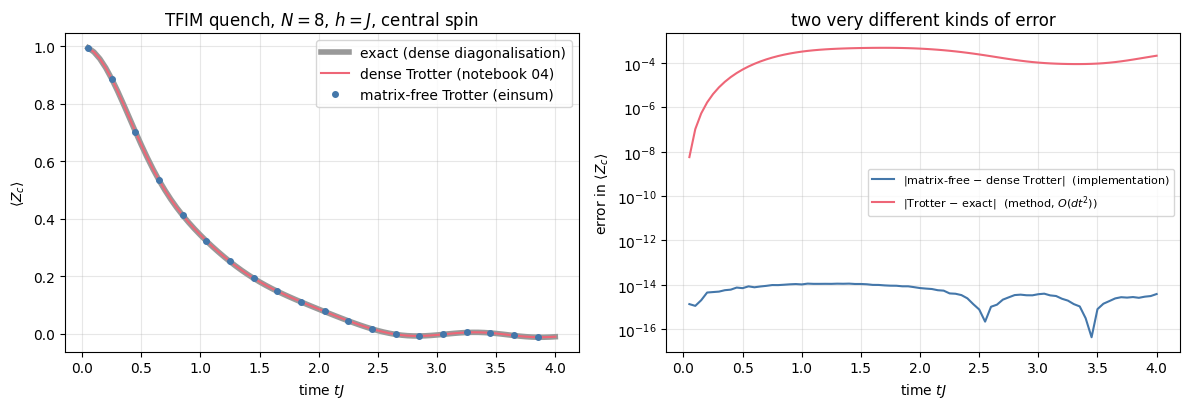

In [25]:
# ==============================================================================
# STEP 17: N=8 TFIM quench -- matrix-free vs dense Trotter (same scheme) vs exact diagonalisation
# ==============================================================================
# ------------------------------------------------------------------------------ PARAMETERS
N_small = 8             # small enough for dense 256 x 256 matrices
J, h_field = 1.0, 1.0   # H = -J sum ZZ - h sum X     (critical point h = J)
dt, n_steps = 0.05, 80  # final time T = 4 / J
# ------------------------------------------------------------------------------
c_small = N_small // 2
terms_small = bond_terms(N_small, Jzz=-J, hx=-h_field)                  # 7 bond terms, fields absorbed
psi0 = zero_state_tensor(N_small)
times = dt * np.arange(1, n_steps + 1)

# (1) matrix-free
run_small = jax.jit(lambda p: evolve_matrix_free(p, terms_small, dt, n_steps, c_small))
psi_T, (mz_free, zz_free, echo_free) = run_small(psi0)

# (2) dense Trotter of notebook 04: the same scheme with 256 x 256 layer matrices
traj_dense = evolve_dense_trotter(psi0.reshape(-1), terms_small, dt, n_steps, N_small)          # (n_steps, 2^N)

# (3) exact evolution by full diagonalisation of the dense Hamiltonian
H_small = build_hamiltonian_dense(N_small, Jxx=0.0, Jyy=0.0, Jzz=-J, hx=-h_field)
w_small, V_small = jnp.linalg.eigh(H_small)
coeff0 = V_small.conj().T @ psi0.reshape(-1)
traj_exact = (V_small @ (jnp.exp(-1j * jnp.asarray(times)[None, :] * w_small[:, None]) * coeff0[:, None])).T   # (n_steps, 2^N)

Zc_dense = site_operator(Z, c_small, N_small)
mz_dense = jnp.real(jnp.einsum("ti,ij,tj->t", traj_dense.conj(), Zc_dense, traj_dense))
mz_exact = jnp.real(jnp.einsum("ti,ij,tj->t", traj_exact.conj(), Zc_dense, traj_exact))

err_state = max_abs_diff(psi_T.reshape(-1), traj_dense[-1])
err_obs = max_abs_diff(mz_free[:, c_small], mz_dense)
err_trotter_state = float(jnp.linalg.norm(traj_dense[-1] - traj_exact[-1]))
err_trotter_obs = max_abs_diff(mz_dense, mz_exact)
norm_drift = abs(float(jnp.linalg.norm(psi_T)) - 1.0)
print(f"IMPLEMENTATION error  matrix-free vs dense Trotter:  final state max|diff| = {err_state:.2e},  <Z_c>(t) max|diff| = {err_obs:.2e}")
print(f"METHOD error          Trotter (dt={dt}) vs exact     :  final state ||diff||  = {err_trotter_state:.2e},  <Z_c>(t) max|diff| = {err_trotter_obs:.2e}")
print(f"norm drift after {n_steps} steps: {norm_drift:.2e}")
assert err_state < TOL and err_obs < TOL and norm_drift < TOL

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.plot(times, mz_exact, "-", color="0.6", lw=4, label="exact (dense diagonalisation)")
ax1.plot(times, mz_dense, "-", color="#EE6677", lw=1.5, label="dense Trotter (notebook 04)")
ax1.plot(times[::4], mz_free[::4, c_small], "o", color="#4477AA", ms=4, label="matrix-free Trotter (einsum)")
ax1.set_xlabel("time $tJ$"); ax1.set_ylabel(r"$\langle Z_c\rangle$"); ax1.set_title(f"TFIM quench, $N={N_small}$, $h=J$, central spin"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.semilogy(times, np.abs(np.asarray(mz_free[:, c_small] - mz_dense)) + 1e-18, "-", color="#4477AA", label="|matrix-free $-$ dense Trotter|  (implementation)")
ax2.semilogy(times, np.abs(np.asarray(mz_dense - mz_exact)) + 1e-18, "-", color="#EE6677", label="|Trotter $-$ exact|  (method, $O(dt^2)$)")
ax2.set_xlabel("time $tJ$"); ax2.set_ylabel(r"error in $\langle Z_c\rangle$"); ax2.set_title("two very different kinds of error"); ax2.legend(fontsize=8); ax2.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

**Interpretation.** The matrix-free evolution reproduces the dense Trotter evolution of notebook 04 to $\sim10^{-14}$ in the
final state and in the observable (blue curve in the right panel: pure round-off). The two codes perform *the same mathematics* —
the same small unitaries in the same order — once with $256\times256$ matrices and once with $4\times4$ matrices and index
contractions. The Trotter approximation itself deviates from the exact solution at the level printed above (red curve), which is far below
the line width of the left panel and can be reduced at will by decreasing $dt$ (error $\propto dt^2$; notebook 12 of Chapter 5 studies this in
depth). The norm is conserved to $\sim10^{-13}$: every gate is unitary up to round-off, and the round-off of the $80\times11$ gate applications accumulates.

For completeness, here are the engine's production versions — `tebd_gates`, `apply_gates` (our `apply_gate_list`) and `tebd_evolve` (our scan loop). `tebd_gates` implements the
symmetric splitting for an **arbitrary ordered list of terms**, $\prod_{k}e^{-ih_kdt/2}\prod_{k\,\rm reversed}e^{-ih_kdt/2}$ (plus orders 1 and 4). *The order of the list defines the scheme*:

* list = even bonds followed by odd bonds: the product is $E(\tfrac{dt}2)\,O(\tfrac{dt}2)\,O(\tfrac{dt}2)\,E(\tfrac{dt}2)=E(\tfrac{dt}2)\,O(dt)\,E(\tfrac{dt}2)$ — *identical* to Eq. (4), since the odd gates commute among themselves;
* list in the natural order $j=0,1,2,\dots$ (or the bonds-then-fields list of `heisenberg_terms`): a different, equally valid second-order scheme — a sequential sweep along the chain and back — whose
  result differs from ours by $O(dt^2)$ while both converge to the exact evolution.

In [26]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi

def tebd_evolve(psi, terms, dt, n_steps, order=2, observe=None):
    """Evolve for n_steps*dt with TEBD and record `observe(psi)` after every step.

    JAX    `lax.scan(step, carry, xs, length)` compiles the step ONCE and loops inside XLA
           (a Python for-loop under jit would unroll n_steps copies of the graph).
           Returns (final_state, stacked_observables).
    """
    gates = tebd_gates(terms, dt, order)

    def step(psi, _):
        psi = apply_gates(psi, gates)
        return psi, (observe(psi) if observe is not None else 0.0)

    return lax.scan(step, psi, None, length=n_steps)


In [27]:
# ==============================================================================
# CHECKPOINT: engine tebd_evolve with different term orderings
# ==============================================================================
terms_eo = [t for t in terms_small if t[0][0] % 2 == 0] + [t for t in terms_small if t[0][0] % 2 == 1]     # even bonds, then odd bonds
psi_T_eo, _ = jax.jit(lambda p: tebd_evolve(p, terms_eo, dt, n_steps, order=2))(psi0)
psi_T_sweep, _ = jax.jit(lambda p: tebd_evolve(p, terms_small, dt, n_steps, order=2))(psi0)                # natural order: sweep
psi_T_hterms, _ = jax.jit(lambda p: tebd_evolve(p, heisenberg_terms(N_small, 0.0, 0.0, -J, hx=-h_field), dt, n_steps, order=2))(psi0)
psi_T_exact = traj_exact[-1].reshape((2,) * N_small)

err_eo = max_abs_diff(psi_T_eo, psi_T)
print(f"engine tebd_evolve, even-then-odd list vs our even/odd Strang code : max|diff| = {err_eo:.2e}   (same scheme -> round-off)")
assert err_eo < TOL
for name, p in [("even/odd Strang (ours, notebook 04)", psi_T), ("engine, sweep over bonds j=0,1,2,...", psi_T_sweep),
                ("engine, heisenberg_terms (bonds, then fields)", psi_T_hterms)]:
    print(f"   distance to the EXACT state at T={dt * n_steps:g}:  {name:46s} ||diff|| = {float(jnp.linalg.norm(p - psi_T_exact)):.2e}")

engine tebd_evolve, even-then-odd list vs our even/odd Strang code : max|diff| = 7.11e-14   (same scheme -> round-off)
   distance to the EXACT state at T=4:  even/odd Strang (ours, notebook 04)            ||diff|| = 2.78e-03
   distance to the EXACT state at T=4:  engine, sweep over bonds j=0,1,2,...           ||diff|| = 3.86e-03
   distance to the EXACT state at T=4:  engine, heisenberg_terms (bonds, then fields)  ||diff|| = 1.26e-02


With the even-then-odd list the engine reproduces our evolution to round-off; the other orderings are *different approximations* of the same exact state. All three errors are $O(dt^2)$, but the
prefactors differ (printed above): here the even/odd scheme with the fields absorbed into the bonds is the most accurate, and the unfused bonds-then-fields list — which also needs the most gates — the
least. How the error depends on the ordering, on $dt$ and on the order of the formula is studied in [notebook 12](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb) (Chapter 5).

### 8.5 Twenty spins: beyond the reach of any dense method

Now the same function, unchanged, for $N=20$: a Hilbert space of dimension $2^{20}=1\,048\,576$. The state occupies 16.8 MB. A single dense
operator would occupy $16\cdot4^{20}$ bytes $=17.6$ TB, and the dense Trotter step matrix of notebook 04 could neither be stored nor computed. One Trotter
step consists of $10+9+10=29$ two-site gates.

In [28]:
# ==============================================================================
# STEP 18: TFIM quench with N = 20 spins, matrix-free
# ==============================================================================
# ------------------------------------------------------------------------------ PARAMETERS
N_big = 20
dt_big, n_steps_big = 0.05, 80          # same Trotter parameters as in the validated N=8 run; T = 4 / J
# ------------------------------------------------------------------------------
c_big = N_big // 2
terms_big = bond_terms(N_big, Jzz=-J, hx=-h_field)
run_big = jax.jit(lambda p: evolve_matrix_free(p, terms_big, dt_big, n_steps_big, c_big))

t0 = time.perf_counter()
psi_T_big, (mz_big, zz_big, echo_big) = jax.block_until_ready(run_big(zero_state_tensor(N_big)))
t_total = time.perf_counter() - t0
times_big = dt_big * np.arange(1, n_steps_big + 1)
corr_big = zz_big - mz_big[:, c_big:c_big + 1] * mz_big                  # connected correlation C_j(t)

print(f"N = {N_big}: Hilbert-space dimension 2^N = {2 ** N_big:,};  state = {psi_T_big.nbytes / 1e6:.1f} MB;  "
      f"a dense operator would need {BYTES * 4.0 ** N_big / 1e12:.1f} TB")
print(f"{n_steps_big} Trotter steps x {len(strang_even_odd_gates(terms_big, dt_big))} two-site gates (+ observables after every step), compile + run: {t_total:.1f} s")
print(f"norm after the evolution: 1 {float(jnp.linalg.norm(psi_T_big)) - 1.0:+.1e}")
E0_big = float(energy(terms_big, zero_state_tensor(N_big))); ET_big = float(energy(terms_big, psi_T_big))
print(f"energy <H>: t=0: {E0_big:.6f}   t=T: {ET_big:.6f}   (relative drift {abs(ET_big - E0_big) / abs(E0_big):.1e})")
assert abs(float(jnp.linalg.norm(psi_T_big)) - 1.0) < TOL

N = 20: Hilbert-space dimension 2^N = 1,048,576;  state = 16.8 MB;  a dense operator would need 17.6 TB
80 Trotter steps x 29 two-site gates (+ observables after every step), compile + run: 10.1 s
norm after the evolution: 1 -1.3e-12


energy <H>: t=0: -19.000000   t=T: -19.001717   (relative drift 9.0e-05)


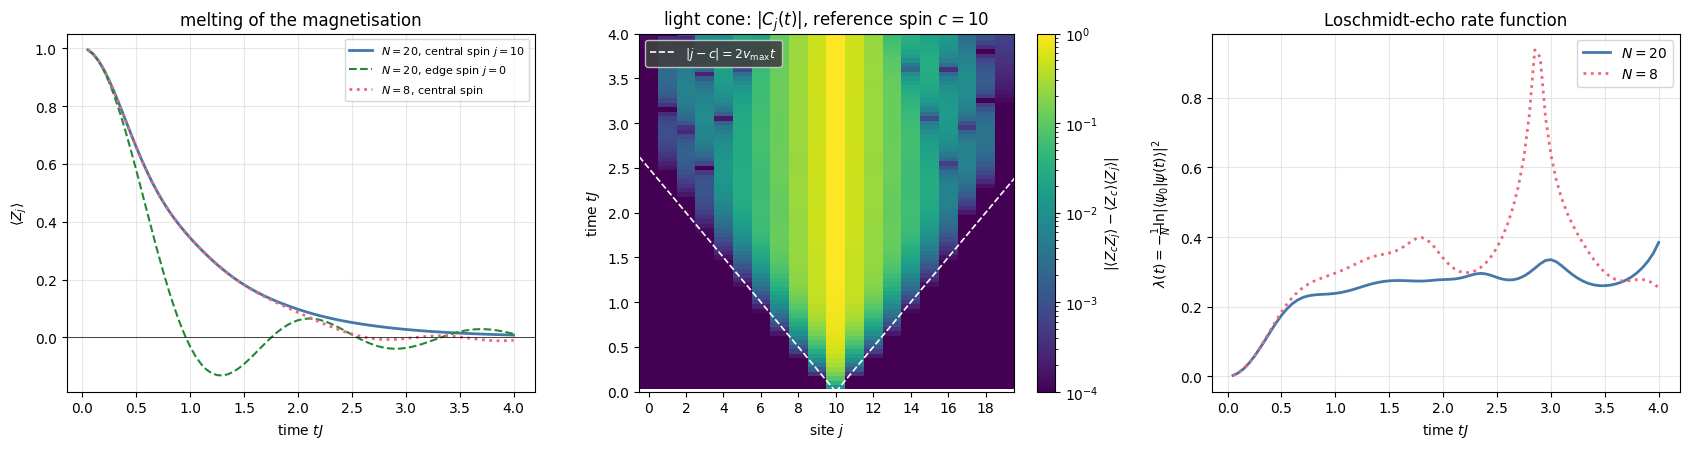

smallest return probability: L = 4.58e-04 at tJ = 4.00
finite size in <Z_c>: |N=8 - N=20| exceeds 1e-2 at tJ = 2.00 and peaks at 0.045 (tJ = 2.70);  edge at distance 4 from the centre, v_max = 2J -> expected tJ = 2.0
measured front (|C| > 1e-3):  d=1: tJ=0.25, d/t=4.0  d=2: tJ=0.50, d/t=4.0  d=3: tJ=0.80, d/t=3.8  d=4: tJ=1.10, d/t=3.6  d=5: tJ=1.40, d/t=3.6  d=6: tJ=1.75, d/t=3.4  d=7: tJ=2.20, d/t=3.2  d=8: tJ=2.50, d/t=3.2      bound 2 v_max/J = 4


In [29]:
# ==============================================================================
# FIGURE: physics of the N=20 quench
# ==============================================================================
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
ax = axes[0]
ax.plot(times_big, mz_big[:, c_big], "-", color="#4477AA", lw=2, label=f"$N={N_big}$, central spin $j={c_big}$")
ax.plot(times_big, mz_big[:, 0], "--", color="#228833", lw=1.5, label=f"$N={N_big}$, edge spin $j=0$")
ax.plot(times, mz_free[:, c_small], ":", color="#EE6677", lw=2, label=f"$N={N_small}$, central spin")
ax.axhline(0, color="k", lw=0.5); ax.set_xlabel("time $tJ$"); ax.set_ylabel(r"$\langle Z_j\rangle$")
ax.set_title("melting of the magnetisation"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
im = ax.pcolormesh(np.arange(N_big), times_big, np.abs(np.asarray(corr_big)) + 1e-12, shading="nearest", cmap="viridis",
                   norm=LogNorm(vmin=1e-4, vmax=1.0))
v_max = 2.0 * J * min(1.0, h_field / J)                                   # maximal quasi-particle group velocity of the TFIM
tt = np.linspace(0, times_big[-1], 50)
ax.plot(c_big + 2 * v_max * tt, tt, "w--", lw=1.2); ax.plot(c_big - 2 * v_max * tt, tt, "w--", lw=1.2, label=r"$|j-c| = 2 v_{\max} t$")
ax.set_xlim(-0.5, N_big - 0.5); ax.set_xticks(range(0, N_big, 2)); ax.set_xlabel("site $j$"); ax.set_ylabel("time $tJ$")
ax.set_ylim(0, times_big[-1]); ax.set_title(rf"light cone: $|C_j(t)|$, reference spin $c={c_big}$"); ax.legend(fontsize=9, loc="upper left", facecolor="0.25", labelcolor="w", framealpha=0.9)
plt.colorbar(im, ax=ax, label=r"$|\langle Z_cZ_j\rangle-\langle Z_c\rangle\langle Z_j\rangle|$")

ax = axes[2]
ax.plot(times_big, -np.log(np.asarray(echo_big)) / N_big, "-", color="#4477AA", lw=2, label=f"$N={N_big}$")
ax.plot(times, -np.log(np.asarray(echo_free)) / N_small, ":", color="#EE6677", lw=2, label=f"$N={N_small}$")
ax.set_xlabel("time $tJ$"); ax.set_ylabel(r"$\lambda(t)=-\frac{1}{N}\ln|\langle\psi_0|\psi(t)\rangle|^2$")
ax.set_title("Loschmidt-echo rate function"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"smallest return probability: L = {float(jnp.min(echo_big)):.2e} at tJ = {times_big[int(jnp.argmin(echo_big))]:.2f}")

def first_time_above(series, threshold, t_axis):
    """Smallest time at which `series` exceeds `threshold` (None if it never does)."""
    hit = np.nonzero(np.asarray(series) > threshold)[0]
    return float(t_axis[hit[0]]) if len(hit) else None


# how much does the SMALL chain differ from the large one?  (the two curves in the left panel are almost on top of each other)
d_fs = np.abs(np.asarray(mz_free[:, c_small] - mz_big[:, c_big]))
t_dep = first_time_above(d_fs, 1e-2, times)                        # first time the difference exceeds 1e-2
print(f"finite size in <Z_c>: |N={N_small} - N={N_big}| exceeds 1e-2 at tJ = {t_dep:.2f} and peaks at {d_fs.max():.3f} "
      f"(tJ = {times[int(np.argmax(d_fs))]:.2f});  edge at distance {N_small // 2} from the centre, v_max = {v_max:.0f}J "
      f"-> expected tJ = {(N_small // 2) / v_max:.1f}")

# measured light cone: when does the correlation at distance d from the centre first exceed 1e-3?
fronts = [(d, first_time_above(np.abs(np.asarray(corr_big[:, c_big + d])), 1e-3, times_big)) for d in range(1, 9)]
print("measured front (|C| > 1e-3):  " + "  ".join(f"d={d}: tJ={t:.2f}, d/t={d / t:.1f}" for d, t in fronts if t)
      + f"      bound 2 v_max/J = {2 * v_max:.0f}")

**Physics of the result.**

* *Left.* The transverse field flips spins, and the initial magnetisation melts on a time scale $\sim1/J$. In the bulk of the long
  chain (blue) the decay is smooth and monotonic over the simulated window. The $N=8$ chain (dotted) follows the same curve and then departs from
  it — the moment when its central spin "learns" about the boundaries. On this scale the departure is barely visible, so read the number printed under the
  figure instead: the two curves stay within $10^{-2}$ until $tJ\approx2$ and then separate by a few times $10^{-2}$. That time is exactly what the
  quasi-particle picture predicts: the central spin of the $N=8$ chain sits $4$ sites from the edge, and the fastest excitation travels at
  $v_{\max}=2J$, so the boundary is felt at $tJ=4/2=2$. The edge spin (green) has a single neighbour, feels a weaker
  ordering field, and departs from the bulk curve immediately — a much larger effect. Twenty spins show *bulk* physics over a time window in which eight spins already show finite-size artefacts.
* *Middle.* Correlations are not created instantaneously everywhere. The quench creates pairs of quasi-particles which fly apart with
  velocity at most $v_{\max}=2J\min(1,h/J)$ (for the TFIM in Pauli convention, quoted here without proof from its exact free-fermion solution); two spins
  become correlated when counter-propagating partners reach them, which bounds the correlated region by $|j-c|\le 2v_{\max}t$ (dashed lines). The
  numbers printed under the figure make this quantitative: the front at which $|C_j|$ first exceeds $10^{-3}$ advances at $|j-c|/t\approx3$–$4$ in
  units of $J$, i.e. just inside the bound $2v_{\max}=4J$. Outside
  this **light cone** correlations are exponentially small (note the logarithmic colour scale) — an instance of the Lieb–Robinson bound and of
  the quasi-particle picture of Calabrese and Cardy. With $N=20$ the cone has room to develop before it hits the edges.
* *Right.* The return probability $\mathcal L\sim e^{-N\lambda(t)}$ decays exponentially with the system size (for 20 spins its minimum, printed above, is already
  below $10^{-3}$), which is why one plots the intensive rate function $\lambda(t)$. At early times the curves for $N=8$ and $N=20$ coincide: $\lambda$ is a bulk quantity.
  Then the small chain develops a pronounced peak near $tJ\approx2.9$, where the $N=20$ curve shows only a gentle bump — a finite-size effect that one could easily have
  mistaken for physics had only $N=8$ been available. Comparing system sizes is the only way to tell the two apart — one more reason to need large $N$.
  (Genuine non-analytic peaks of $\lambda(t)$ in the thermodynamic limit, *dynamical quantum phase transitions* (Heyl, Polkovnikov and Kehrein 2013), occur for
  quenches *across* the critical point; you can look for their precursors in Exercise 6.)

The energy $\langle H\rangle$ is conserved up to the small Trotter error printed above (exactly conserved would require the exact propagator), and the norm to round-off.

## 9. Cost model: $O(2^k\,2^N)$ confronted with measurement

**Operation count.** For every one of the $2^{N-k}$ configurations of the spectator spins, Eq. (3) multiplies a $2^k\times2^k$ matrix with
a $2^k$-vector: $2^{N-k}\cdot4^k=2^k\,2^N$ multiplications. Our even/odd Strang step of an open chain (even $N$) contains $\tfrac N2+(\tfrac N2-1)+\tfrac N2=\tfrac{3N}2-1$
two-site gates, hence

$$ T_{\rm step}\;\approx\;\big(\tfrac{3N}{2}-1\big)\cdot4\cdot2^N\,\tau\;=\;(6N-4)\,2^N\,\tau, $$

with $\tau$ an effective time per multiplication. **Memory**: the state, one output buffer, and temporaries of the same size — a small multiple of
$16\cdot2^N$ bytes. Compare: dense Trotter needs $16\cdot4^N$ bytes and $4^N$ multiplications per step, plus an $O(8^N)$ set-up.

We measure (i) the time per Trotter step (observables excluded) as a function of $N$ and (ii) the time per gate as a function of $k$ at fixed $N$.

   N | gates/step | compile [s] | run per step [ms] | per gate per amplitude [ns] | time(N)/time(N-2): measured | model
   8 |         11 |        0.06 |             0.030 |                      10.517 |                          -- |    --
  10 |         14 |        0.08 |             0.087 |                       6.056 |                        2.93 |  5.09
  12 |         17 |        0.09 |             0.320 |                       4.595 |                        3.68 |  4.86
  14 |         20 |        0.10 |             2.040 |                       6.227 |                        6.38 |  4.71
  16 |         23 |        0.12 |             3.180 |                       2.109 |                        1.56 |  4.60
  18 |         26 |        0.14 |            12.975 |                       1.904 |                        4.08 |  4.52
  20 |         29 |        0.17 |            82.236 |                       2.704 |                        6.34 |  4.46

fit of log2(time per step) vs N over N 

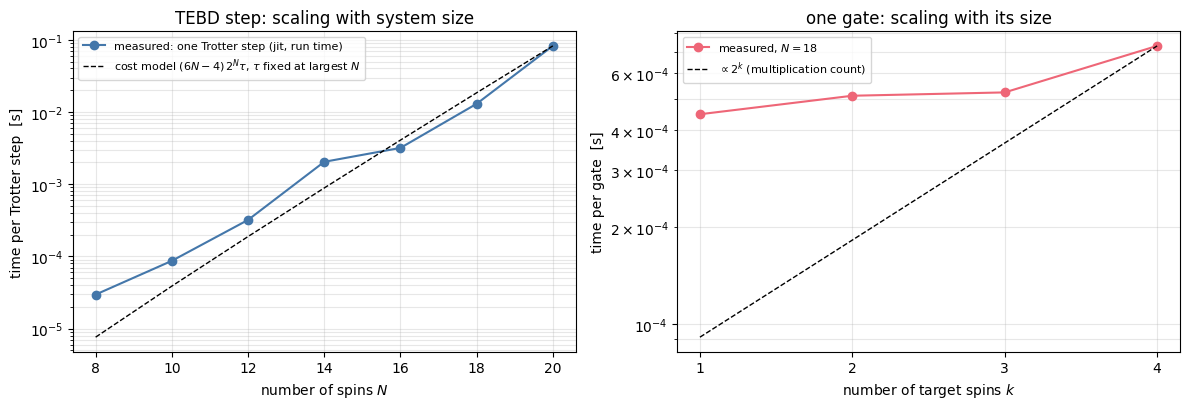

In [30]:
# ==============================================================================
# STEP 19: measured cost per Trotter step vs N, and per gate vs k
# ==============================================================================
# ------------------------------------------------------------------------------ PARAMETERS
N_COST = [8, 10, 12, 14, 16, 18, 20]
N_FOR_K, K_LIST = 18, [1, 2, 3, 4]
# ------------------------------------------------------------------------------
t_step, t_compile, n_gates_step = {}, {}, {}
for n in N_COST:
    gates_n = strang_even_odd_gates(bond_terms(n, Jzz=-J, hx=-h_field), dt)
    one_step = jax.jit(lambda p: apply_gate_list(p, gates_n))
    first, best = time_fn(one_step, zero_state_tensor(n))
    t_step[n], t_compile[n], n_gates_step[n] = best, first - best, len(gates_n)

k_cost, key = jax.random.split(key)
state_k = random_state(k_cost, N_FOR_K).reshape((2,) * N_FOR_K)
t_gate = {}
for k in K_LIST:
    qubits_k = tuple(range(2, 2 + 2 * k, 2))                                   # k non-adjacent targets: 2, 4, 6, ...
    Uk = jnp.eye(2 ** k, dtype=CDTYPE) + 0.1 * jnp.ones((2 ** k, 2 ** k), dtype=CDTYPE)   # any dense 2^k x 2^k matrix
    t_gate[k] = time_fn(jax.jit(lambda p, U: apply_gate(p, U, qubits_k)), state_k, Uk)[1]

cost_model = lambda n: (6 * n - 4) * 2.0 ** n                                  # multiplications per step / 1
print("   N | gates/step | compile [s] | run per step [ms] | per gate per amplitude [ns] | time(N)/time(N-2): measured | model")
prev = None
for n in N_COST:
    n_gates = n_gates_step[n]
    ratio = f"{t_step[n] / t_step[prev]:27.2f} | {cost_model(n) / cost_model(prev):5.2f}" if prev else f"{'--':>27s} | {'--':>5s}"
    print(f"  {n:2d} | {n_gates:10d} | {t_compile[n]:11.2f} | {t_step[n] * 1e3:17.3f} | {t_step[n] / (n_gates * 2 ** n) * 1e9:27.3f} | " + ratio)
    prev = n
slope = np.polyfit(N_COST[-4:], np.log2([t_step[n] for n in N_COST[-4:]]), 1)[0]
slope_model = np.polyfit(N_COST[-4:], np.log2([cost_model(n) for n in N_COST[-4:]]), 1)[0]
print(f"\nfit of log2(time per step) vs N over N = {N_COST[-4:]}:  measured slope = {slope:.2f},  cost model = {slope_model:.2f}")
print(f"\ntime per k-site gate at N = {N_FOR_K}:  " + "   ".join(f"k={k}: {t_gate[k] * 1e3:.2f} ms" for k in K_LIST)
      + "\n   ratios t(k+1)/t(k): " + "   ".join(f"{t_gate[k + 1] / t_gate[k]:.2f}" for k in K_LIST[:-1]) + "      (multiplication count: 2.00)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ns = np.array(N_COST, dtype=float)
ax1.semilogy(ns, [t_step[n] for n in N_COST], "o-", color="#4477AA", label="measured: one Trotter step (jit, run time)")
model = cost_model(ns)
ax1.semilogy(ns, model * t_step[N_COST[-1]] / model[-1], "k--", lw=1, label=r"cost model $(6N-4)\,2^N\tau$, $\tau$ fixed at largest $N$")
ax1.set_xlabel("number of spins $N$"); ax1.set_ylabel("time per Trotter step  [s]"); ax1.set_title("TEBD step: scaling with system size")
ax1.grid(True, which="both", alpha=0.3); ax1.legend(fontsize=8)
ks = np.array(K_LIST, dtype=float)
ax2.semilogy(ks, [t_gate[k] for k in K_LIST], "o-", color="#EE6677", label=f"measured, $N={N_FOR_K}$")
ax2.semilogy(ks, t_gate[K_LIST[-1]] * 2.0 ** (ks - ks[-1]), "k--", lw=1, label=r"$\propto 2^k$ (multiplication count)")
ax2.set_xticks(K_LIST); ax2.set_xlabel("number of target spins $k$"); ax2.set_ylabel("time per gate  [s]"); ax2.set_title("one gate: scaling with its size")
ax2.grid(True, which="both", alpha=0.3); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Confronting model and measurement.**

* *Scaling with $N$ (left).* The small sizes sit above the model line — launching a couple of dozen compiled kernels costs more than the arithmetic inside them — and the measured curve bends down onto the model as $N$ grows.
  The exponential law itself is unmistakable: between $N=8$ and $N=20$ the time per step grows by more than three orders of magnitude. Two more spins multiply it by a factor whose model value is
  $4\,(6N-4)/(6N-16)$, which decreases from $\approx5.1$ at $N=10$ to $\approx4.5$ at $N=20$ (last two columns of the table; factor 4 from the Hilbert-space dimension, the rest from the additional gates)
  and whose measured values scatter around it, and the fitted slope of $\log_2T$ versus $N$ over the four largest
  sizes lands below the model slope (both are printed above): the measured growth is slower than the operation count because the fixed overheads, which inflate the small-$N$ times, shrink in relative importance as $N$ grows. Do not read more than that out of the individual numbers. The column "per gate per amplitude" — the effective $\tau$ times $2^k=4$ —
  is a few nanoseconds at the larger sizes (several times that at the smallest, where the fixed overheads still dominate) and drifts downwards as those overheads lose importance; it is not exactly constant, and a single entry can be off by a factor of two when other jobs compete for the
  processor or when the state stops fitting into a level of cache. The cost model counts multiplications; the hardware also charges for overhead and memory traffic.
* *Scaling with $k$ (right).* The multiplication count predicts a factor 2 per additional target spin, and the dashed line has that slope. The measured curve is much flatter: the ratios printed above stay at or below that predicted factor 2,
  and are typically much closer to 1: a gate on four spins does four times the arithmetic of a gate on two and takes roughly the same time. The reason is that every gate reads and writes all $2^N$ amplitudes exactly once regardless of $k$, so the extra
  multiplications of a larger gate hide behind memory traffic that has to be paid anyway. Larger gates are therefore "cheaper per multiplication", which is why simulators *fuse* gates:
  we already did so when we absorbed the single-site field terms into the bond gates ($\tfrac{3N}2-1$ two-site gates per step instead of the $2(2N-1)$ gates of the unfused `heisenberg_terms` list), and merging the
  two half-layers of consecutive steps saves another third (Exercise 5).
* *Compilation* grows with the number of gates in the step (the circuit is unrolled at trace time) but not with $2^N$, and thanks to `lax.scan` it
  is paid once, not once per time step.

> **Numerical practice.** A cost model is a hypothesis. Measure it. Where it fails (small $N$: overhead; large $N$: memory bandwidth) you learn
> something about your computer that no operation count will tell you.

## 10. Summary — key takeaways

* **A state of $N$ spins is a rank-$N$ tensor** $\psi[s_0,\dots,s_{N-1}]$; `reshape((2,)*N)` converts from the vector of notebook 03 at zero cost. Axis $q$ = spin $q$;
  the flat index is $i=\sum_qs_q2^{N-1-q}$ (spin 0 = most significant bit = leftmost Kronecker factor).
* **An operator on spin $q$ is a contraction with axis $q$**: $\psi'[..a..]=\sum_bU[a,b]\psi[..b..]$, e.g. `"Bb,abc->aBc"`. The identities of
  $\mathbb1\otimes\dots\otimes U\otimes\dots\otimes\mathbb1$ are never written, stored or multiplied.
* **Two-site operators**: `U4.reshape(2,2,2,2)` $=U[a_1,a_2,b_1,b_2]$ (outputs first, inputs second; first spin = left Kronecker factor). The tuple `(q1,q2)` wires
  the operator's first/second spin to any two axes — neighbours, distant, or reversed — at identical cost; the output string always keeps the axis order of $\psi$.
* **`apply_gate`** builds the einsum string by program (fresh letters for the targets, replaced in place). `qubits` are static Python ints, states and matrices are
  traced — so the function composes with `jit`, `vmap`, `scan` (and later `grad`). It is *the* primitive of this course.
* **Cost**: $O(2^k2^N)$ time and $O(2^N)$ memory versus $O(4^N)$/$O(4^N)$ for dense operators. Measured: $2^N$ scaling at large $N$, overhead-dominated at small $N$,
  memory-bound at small $k$. einsum, tensordot and transpose+matmul are equivalent up to factors of order one; einsum wins on clarity.
* **A Hamiltonian is a list of local terms**; $H|\psi\rangle=\sum_kh_k|\psi\rangle$ costs $O(N2^N)$. The dense matrix, when needed for validation, is recovered
  column by column with `vmap` (`dense_hamiltonian`).
* **Trotter gates $e^{-ih_kdt}$ are small unitaries** applied by the same einsum: TEBD on a state vector. The matrix-free code reproduces the dense Trotter code to
  $\sim10^{-14}$ at $N=8$ and then runs $N=20$ — a million amplitudes — where a single dense operator would need 17.6 TB.
* **Habit**: every new primitive was validated against an independent brute-force reference before being used. Do the same in your own work.

## 11. Exercises

1. ★ **Strings by hand.** For $N=5$ write by hand the einsum strings for (a) a one-site operator on $q=3$, (b) a two-site operator on $(1,4)$, (c) on $(4,1)$.
   Verify each against `site_operator`/`two_site_operator_any` with `max_abs_diff(...) < TOL`, then compare with `gate_einsum_string`.
2. ★ **Little-endian world.** Suppose a colleague stores states with spin 0 as the *least* significant bit. Show that her vector is obtained from our tensor by
   `psi.transpose(range(N-1,-1,-1)).reshape(-1)`, and verify with `site_operator` that an operator on our spin $q$ is an operator on her spin $N-1-q$.
3. ★★ **Operators from the left and from the right.** Implement $\langle\phi|M_q$ (a bra acted upon from the right), i.e. $\phi'^*[..b..]=\sum_a\phi^*[..a..]M[a,b]$, with
   one hand-written einsum for $N=3$, and check $\big(\langle\phi|M_q\big)|\psi\rangle=\langle\phi|\big(M_q|\psi\rangle\big)$. Which matrix do you have to pass to
   `apply_gate` to get the same result? (Answer: $M^T$ acting on the conjugated tensor — this is how density matrices are evolved in notebook 07.)
4. ★★ **Extend the code: a three-site reference.** Generalise `two_site_operator_any` to $k$ sites by expanding the $2^k\times2^k$ matrix in products of $k$ Pauli matrices,
   and use it to validate `apply_gate` for a random three-site operator on the non-contiguous, unordered sites $(4,0,2)$ of $N=5$ spins. Apply the Toffoli gate (doubly-controlled X) with controls 4 and 0 and target 2 to a basis state.
5. ★★ **Extend the code: merging half steps.** In $n$ consecutive Strang steps the final $E(dt/2)$ of one step and the initial $E(dt/2)$ of the next combine into a single $E(dt)$:
   $U^n=E(\tfrac{dt}2)\,[O(dt)E(dt)]^{n-1}O(dt)\,E(\tfrac{dt}2)$. Implement this with `lax.scan` (observables are then available only at the end, or must be computed on a copy
   of the state to which the missing half layer has been applied), verify agreement with `evolve_matrix_free` to round-off, and measure the speed-up at $N=18$. Compare also with the
   *unfused* term list of `heisenberg_terms` ($2(2N-1)$ gates per step): how much does absorbing the fields into the bonds save?
6. ★★ **Physics: quench into the two phases.** Repeat the $N=20$ quench for $h/J=0.5$ (ferromagnetic side) and $h/J=2$ (paramagnetic side). How do the decay of the
   magnetisation and the opening angle of the light cone change? Compare with $v_{\max}=2J\min(1,h/J)$. For $h/J=2$ the quench crosses the critical point: compare the rate function $\lambda(t)$ for $N=8,12,16,20$ —
   do its peaks sharpen with $N$ (precursors of dynamical quantum phase transitions)?
7. ★★★ **Long-range interactions.** Build the term list of $H=\sum_{i<j}\frac{J}{|i-j|^{3}}Z_iZ_j-h\sum_iX_i$ (the `bonds` argument of `heisenberg_terms` gives every pair the *same* coupling, so write
   your own list comprehension with a distance-dependent prefactor), validate it against a dense construction for $N=6$, and run the quench for $N=16$. Is there still a
   sharp light cone? How does the cost per Trotter step scale with $N$ now?
8. ★★★ **Trotter error scaling, matrix-free.** Using the exact $N=8$ reference of §8.4, plot the final-state error of `tebd_evolve` for `order=1,2,4` versus $dt$ on a
   log–log scale with reference slopes 1, 2 and 4. At which $dt$ does round-off take over for order 4?

## 12. References

* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information* (Cambridge University Press, 2000) — tensor products, gates and circuits.
* A. W. Sandvik, *Computational studies of quantum spin systems*, AIP Conf. Proc. **1297**, 135 (2010) — bit representation of spin states, exact diagonalisation.
* K. De Raedt *et al.*, *Massively parallel quantum computer simulator*, Comput. Phys. Commun. **176**, 121 (2007) — state-vector simulation by local updates of amplitudes.
* M. Suzuki, *Generalized Trotter's formula and systematic approximants of exponential operators and inner derivations with applications to many-body problems*, Commun. Math. Phys. **51**, 183 (1976).
* G. Vidal, *Efficient simulation of one-dimensional quantum many-body systems*, Phys. Rev. Lett. **93**, 040502 (2004) — the TEBD algorithm.
* U. Schollwöck, *The density-matrix renormalization group in the age of matrix product states*, Ann. Phys. **326**, 96 (2011) — Trotter gates and tensor-network notation.
* E. H. Lieb and D. W. Robinson, *The finite group velocity of quantum spin systems*, Commun. Math. Phys. **28**, 251 (1972).
* P. Calabrese and J. Cardy, *Time dependence of correlation functions following a quantum quench*, Phys. Rev. Lett. **96**, 136801 (2006) — quasi-particle light cone.
* M. Heyl, A. Polkovnikov and S. Kehrein, *Dynamical quantum phase transitions in the transverse-field Ising model*, Phys. Rev. Lett. **110**, 135704 (2013).
* J. Bradbury *et al.*, *JAX: composable transformations of Python+NumPy programs* (2018), http://github.com/jax-ml/jax ; documentation of `jax.numpy.einsum`, `jax.jit`, `jax.vmap`, `jax.lax.scan`.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644) · [GitHub](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*.

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/